# Pneumonia Classification Challenge
**Medical Imaging_Assignment 1**

Zichen Zhao (25011189)

Goal: "lung opacity consistent with possible pneumonia" (positive) or "no such opacity" (negative).

## 0. Setup
### 0.1 Configuration

In [1]:
from pathlib import Path

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

CACHE_DIR = Path("data/cache")       # preprocessed 224 x 224 images and DICOM header table 
RUN_DIR = Path("outputs/runs")       # model checkpoints and training logs 
IMG_SIZE = 224                       # every image is resized to IMG_SIZE x IMG_SIZE
SPLIT_SEED = 2440                    # fixes the train/val/test split; never changed
TRAIN_SEEDS = [0, 1, 2]              # seeds for training randomness (head init, batch order, augmentation)
RETRAIN = False                      # False: reuse a saved run if its settings match

### 0.2 Imports, device and seeds

In [2]:
import copy
import json
import random
import time
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import pydicom
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.transforms import v2 as T
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# Figure helpers: the plot style (paper_plot_style.py) and radiograph / Grad-CAM drawing (plotting.py)
from helpers.paper_plot_style import (figsize, method_style, finish, label_lines, callout, band, text_color,
                                      RED, PETROL, SLATE, OXBLOOD, GOLD, NEUTRALS, INK, MUTED, RULE,
                                      LABEL_PT, TICK_PT)
from helpers.plotting import (POS, NEG, BOX, tint, readable_on, save_and_show, show_xray, overlay_cam, place_text,
                              style_table)

pd.set_option("display.width", 140)

# Use the fastest available hardware: Apple-silicon GPU (MPS), else an NVIDIA GPU (CUDA), else the CPU.
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    """Seed every random-number generator used in this notebook (Python, NumPy, PyTorch CPU/GPU)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)                      # also seeds CUDA if present
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(SPLIT_SEED)          # for the data-inspection steps; each training run sets its own seed
print(f"device: {DEVICE} | torch {torch.__version__} | torchvision {torchvision.__version__} "
      f"| pydicom {pydicom.__version__} | numpy {np.__version__}")

device: mps | torch 2.14.0 | torchvision 0.29.0 | pydicom 3.0.2 | numpy 2.5.3


### 0.3 Verify the download (Step 5 of the brief)

In [3]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))  

print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

DICOM files found: 25684
Label file found: True
Mapping file found: True


---
## A. Define the task and inspect the data

**Task definition.**
* **Input:** one frontal chest radiograph, stored as a DICOM file. The model sees it as a single-channel 224 × 224 tensor.
* **Output:** a probability *p* ∈ [0, 1] that the image contains lung opacity consistent with possible pneumonia. A decision threshold chosen on the validation set turns *p* into a positive/negative call.
* **Clinical question:** *Does this chest X-ray show a lung opacity that a radiologist would flag as possible pneumonia, so that the study should be read first?*

**Limitations of the target.**
1. **A negative label is not a normal image.** Negatives combine the challenge's *Normal* and *No Lung Opacity / Not Normal* images, so many of them show other problems such as effusions, a large heart or devices.
2. **The label is a proxy.** Radiologists marked possible pneumonia on the image alone, without lab results or follow-up. Our numbers therefore measure agreement with their annotations, not accuracy for the disease itself.
3. All images come from one hospital (NIH Clinical Center), so the results may not hold elsewhere.

### A.1 Labels
A positive exam has one row per bounding box. The exam label is 1 if any of its rows has `Target = 1`, which is the maximum of `Target`. The RSNA `patientId` identifies an exam, not a person, so we join the mapping file to get the NIH patient ID.

In [4]:
labels_raw = pd.read_csv(LABEL_FILE)
mapping = pd.read_csv(MAPPING_FILE, dtype={"nih_patient_id": str})

exams = (labels_raw.groupby("patientId")
         .agg(y=("Target", "max"),              # 1 if ANY row of this exam is positive
              n_boxes=("x", "count"))           # count() skips NaN, so negatives get 0 boxes
         .reset_index())

# The same exam must never carry both labels, and boxes must exist exactly for positive exams.
assert (labels_raw.groupby("patientId").Target.nunique() == 1).all()
assert ((exams.n_boxes > 0) == (exams.y == 1)).all()

# Join the RSNA -> NIH mapping. validate="one_to_one" raises an error if any exam maps to 2+ patients.
exams = exams.merge(mapping, on="patientId", how="left", validate="one_to_one")
assert exams.nih_patient_id.notna().all(), "every exam must have an NIH patient id"

# Bounding boxes per exam (original 1024-px coordinates), used later for figures and Grad-CAM checks.
BOXES = {pid: list(g[["x", "y", "width", "height"]].itertuples(index=False, name=None))
         for pid, g in labels_raw[labels_raw.Target == 1].groupby("patientId")}

print(f"annotation rows : {len(labels_raw):,}")
print(f"examinations    : {len(exams):,}")
exams.head()

annotation rows : 28,989
examinations    : 25,684


,patientId,y,n_boxes,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,0,0,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,0,0,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,0,0,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,0,0,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,0,0,00004082,00004082_008.png


### A.2 DICOM headers
We read only the header of each file (`stop_before_pixels=True`), keep the fields we need later, and cache the table.

In [5]:
def read_dicom_header(path):
    """Return the header fields we need from one DICOM file (pixels are not decoded)."""
    ds = pydicom.dcmread(path, stop_before_pixels=True)
    return {
        "patientId": path.stem,
        "sop_instance_uid": str(ds.SOPInstanceUID),
        "dicom_patient_id": str(ds.PatientID),
        "rows": int(ds.Rows), "cols": int(ds.Columns),
        "photometric": str(ds.PhotometricInterpretation),
        "bits_stored": int(ds.BitsStored),
        "modality": str(ds.get("Modality", "")),
        "body_part": str(ds.get("BodyPartExamined", "")),
        "view": str(ds.get("ViewPosition", "")),
        "sex": str(ds.get("PatientSex", "")),
        "age": int(ds.get("PatientAge", -1)),
        "pixel_spacing_mm": float(ds.PixelSpacing[0]) if "PixelSpacing" in ds else np.nan,
        "transfer_syntax": str(ds.file_meta.TransferSyntaxUID.name),
        "path": str(path),
    }

header_file = CACHE_DIR / "dicom_headers.csv"
if header_file.exists():
    headers = pd.read_csv(header_file)
    print(f"loaded cached header table ({len(headers):,} rows) from {header_file}")
else:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    with ThreadPoolExecutor(max_workers=8) as pool:                  # 8 files at a time: reading is disk-bound
        headers = pd.DataFrame(pool.map(read_dicom_header, dicom_files))
    headers.to_csv(header_file, index=False)
    print(f"read {len(headers):,} DICOM headers -> {header_file}")

# The file name is the image's SOPInstanceUID, which is the `patientId` used in the label file.
assert (headers.patientId == headers.sop_instance_uid).all()
assert headers.patientId.is_unique
assert set(headers.patientId) == set(exams.patientId), "labels and DICOM files must describe the same exams"

# The DICOM PatientID tag cannot identify people either: it is a different random UUID for every file.
print(f"DICOM PatientID tag: {headers.dicom_patient_id.nunique():,} unique values for {len(headers):,} files "
      "-> repeat exams of one person can only be linked through the supplied NIH mapping")

exams = (exams.merge(headers.drop(columns=["sop_instance_uid", "dicom_patient_id"]), on="patientId", validate="one_to_one")
              .sort_values("patientId").reset_index(drop=True))   # fixed row order used everywhere below

loaded cached header table (25,684 rows) from data/cache/dicom_headers.csv
DICOM PatientID tag: 25,684 unique values for 25,684 files -> repeat exams of one person can only be linked through the supplied NIH mapping


### A.3 Exams, patients and classes

In [6]:
n_exams = len(exams)
n_patients = exams.nih_patient_id.nunique()
class_counts = exams.y.value_counts().sort_index()
exams_per_patient = exams.groupby("nih_patient_id").size()

summary = pd.DataFrame({
    "count": [n_exams, n_patients, class_counts[0], class_counts[1]],
    "proportion of exams": [1.0, np.nan, class_counts[0] / n_exams, class_counts[1] / n_exams],
}, index=["unique examinations (patientId)", "unique source patients (nih_patient_id)",
          "negative exams (y = 0)", "positive exams (y = 1)"])
display(style_table(summary, precision=4, caption="Dataset summary"))

print(f"exams per source patient: median {exams_per_patient.median():.0f}, mean {exams_per_patient.mean():.2f}, "
      f"max {exams_per_patient.max()}; {(exams_per_patient > 1).sum():,} patients "
      f"({(exams_per_patient > 1).mean():.1%}) have more than one exam")
print(f"positive exams have {exams.loc[exams.y == 1, 'n_boxes'].value_counts().sort_index().to_dict()} boxes "
      "(number of boxes: number of exams)")

,count,proportion of exams
unique examinations (patientId),"25,684",1.0000
unique source patients (nih_patient_id),"11,171",–
negative exams (y = 0),"20,025",0.7797
positive exams (y = 1),"5,659",0.2203


exams per source patient: median 1, mean 2.30, max 63; 4,198 patients (37.6%) have more than one exam
positive exams have {1: 2481, 2: 3062, 3: 105, 4: 11} boxes (number of boxes: number of exams)


PASS A2_dataset_overview: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/A2_dataset_overview.png


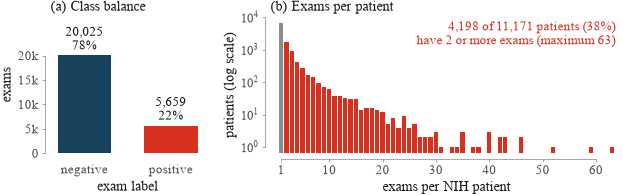

In [7]:
fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.32), width_ratios=[0.7, 1.6])

ax = axes[0]                                                   # (a) class balance
ax.bar([0, 1], class_counts.values, width=0.62, color=[NEG, POS])
for x, n in zip([0, 1], class_counts.values):
    ax.text(x, n + 500, f"{n:,}\n{n / n_exams:.0%}", ha="center", va="bottom", fontsize=TICK_PT)
ax.set_xticks([0, 1], ["negative", "positive"])
ax.set_xlabel("exam label")
ax.set_ylabel("exams")
ax.set_title("(a) Class balance")
finish(ax, y="k", categorical="x")
ax.set_ylim(0, class_counts.max() * 1.4)

ax = axes[1]                                                   # (b) exams per source patient
counts = exams_per_patient.value_counts().sort_index()
ax.bar(counts.index, counts.values, width=0.8, color=[NEUTRALS[1] if k == 1 else POS for k in counts.index])
ax.set_yscale("log")
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel("exams per NIH patient")
ax.set_ylabel("patients (log scale)")
ax.set_title("(b) Exams per patient")
finish(ax)
ax.set_xticks([1, 10, 20, 30, 40, 50, 60])
ax.set_xlim(-1, 65)
ax.spines["bottom"].set_bounds(1, 60)
multi = exams_per_patient > 1
place_text(ax, f"{multi.sum():,} of {n_patients:,} patients ({multi.mean():.0%})\nhave 2 or more exams (maximum {exams_per_patient.max()})",
           prefer=(0.98, 0.97), color=text_color(POS))
fig.get_layout_engine().set(wspace=0.06)
save_and_show(fig, "A2_dataset_overview")

**Figure A2.** Only 22% of exams are positive, and 38% of patients have more than one exam. (a) Exams per label. (b) Exams per patient on a log scale; red bars are patients with two or more exams.

### A.4 Image size, photometric interpretation and projection
These header fields tell us whether any image needs padding or inversion before use.

In [8]:
header_checks = {
    "image size (rows x cols)": (exams.rows.astype(str) + " x " + exams.cols.astype(str)).value_counts().to_dict(),
    "photometric interpretation": exams.photometric.value_counts().to_dict(),
    "bits stored": exams.bits_stored.value_counts().to_dict(),
    "modality": exams.modality.value_counts().to_dict(),
    "body part examined": exams.body_part.value_counts().to_dict(),
    "view position": exams.view.value_counts().to_dict(),
    "patient sex": exams.sex.value_counts().to_dict(),
    "pixel spacing (mm)": exams.pixel_spacing_mm.round(3).value_counts().head(4).to_dict(),
    "transfer syntax": exams.transfer_syntax.value_counts().to_dict(),
}
for field, values in header_checks.items():
    print(f"{field:<28} {values}")
print(f"{'patient age (years)':<28} median {exams.age.median():.0f}, range {exams.age.min()}–{exams.age.max()}; "
      f"{(exams.age > 100).sum()} exams record an implausible age > 100")

# y is 0/1, so per projection: size = number of exams, sum = number of positives, mean = share positive
view_table = (exams.groupby("view").y.agg(exams="size", positives="sum", prevalence="mean"))
display(style_table(view_table, precision=3, caption="Prevalence by projection"))

image size (rows x cols)     {'1024 x 1024': 25684}
photometric interpretation   {'MONOCHROME2': 25684}
bits stored                  {8: 25684}
modality                     {'CR': 25684}
body part examined           {'CHEST': 25684}
view position                {'PA': 13979, 'AP': 11705}
patient sex                  {'M': 14593, 'F': 11091}
pixel spacing (mm)           {0.143: 8674, 0.168: 8481, 0.139: 5288, 0.171: 1923}
transfer syntax              {'JPEG Baseline (Process 1)': 25684}
patient age (years)          median 49, range 1–155; 5 exams record an implausible age > 100


,exams,positives,prevalence
view,,,
AP,"11,705","4,395",0.375
PA,"13,979","1,264",0.090


PASS A4_acquisition_metadata: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/A4_acquisition_metadata.png


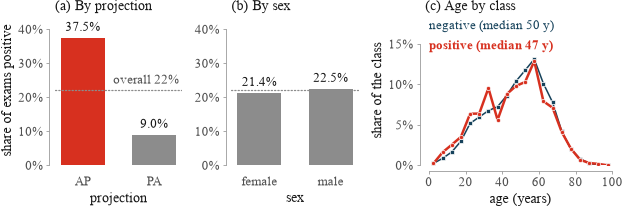

In [9]:
fig, axes = plt.subplots(1, 3, figsize=figsize("full", aspect=0.34), width_ratios=[1, 1, 1.5])
overall = exams.y.mean()

def prevalence_bars(ax, table, colors, labels):
    """Bars of the positive share per group (value on top), on a shared 0-40% axis, with the overall prevalence dotted."""
    ax.bar(range(len(table)), table.prevalence, width=0.62, color=colors)
    for x, value in enumerate(table.prevalence):
        ax.text(x, value + 0.012, f"{value:.1%}", ha="center", va="bottom", fontsize=TICK_PT)
    ax.axhline(overall, color=NEUTRALS[1], lw=0.9, ls=":")
    ax.set_xticks(range(len(table)), labels)
    ax.set_ylabel("share of exams positive")
    finish(ax, y="pct1", categorical="x")
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
    ax.set_ylim(0, 0.44)
    ax.spines["left"].set_bounds(0, 0.4)

ax = axes[0]                                                   # (a) prevalence by projection
views = view_table.reindex(["AP", "PA"])
prevalence_bars(ax, views, [POS, NEUTRALS[1]], ["AP", "PA"])
ax.set_xlabel("projection")
ax.set_title("(a) By projection")
ax.text(1.35, overall + 0.012, f"overall {overall:.0%}", ha="right", va="bottom", fontsize=TICK_PT, color=MUTED)

ax = axes[1]                                                   # (b) prevalence by sex
sexes = exams.groupby("sex").y.agg(prevalence="mean", n="size").reindex(["F", "M"])
prevalence_bars(ax, sexes, [NEUTRALS[1], NEUTRALS[1]], ["female", "male"])
ax.set_ylabel("")
ax.set_xlabel("sex")
ax.set_title("(b) By sex")

ax = axes[2]                                                   # (c) age by class: share of each class per 5-year bin
bins = np.arange(0, 101, 5)
median_age = {}
for label, color, lw, marker in [(0, NEG, 1.1, "s"), (1, POS, 1.8, "o")]:
    ages = exams.loc[(exams.y == label) & (exams.age <= 100), "age"]
    share = np.histogram(ages, bins=bins)[0] / len(ages)
    ax.plot(bins[:-1] + 2.5, share, color=color, lw=lw, marker=marker, ms=3, mec="white", mew=0.5,
            label="positive" if label else "negative")
    median_age[label] = ages.median()
ax.set_xlabel("age (years)")
ax.set_ylabel("share of the class")
ax.set_title("(c) Age by class")
finish(ax, y="pct1")
ax.set_ylim(0, 0.185)
place_text(ax, f"negative (median {median_age[0]:.0f} y)", prefer=(0.02, 0.97), color=text_color(NEG))
place_text(ax, f"positive (median {median_age[1]:.0f} y)", prefer=(0.02, 0.85), fontweight="bold", color=text_color(POS))
fig.get_layout_engine().set(wspace=0.06)
save_and_show(fig, "A4_acquisition_metadata")

**Figure A4.** AP images are four times as often positive as PA images (37.5% vs 9.0%), while sex and age differ little between the classes.

### A.5 Representative images
The examples are picked by fixed rules rather than by eye: one negative and one positive per projection, the smallest opacity, the exam with the most boxes, the darkest image, and an exam with an impossible age.

PASS A3_representative_images: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/A3_representative_images.png


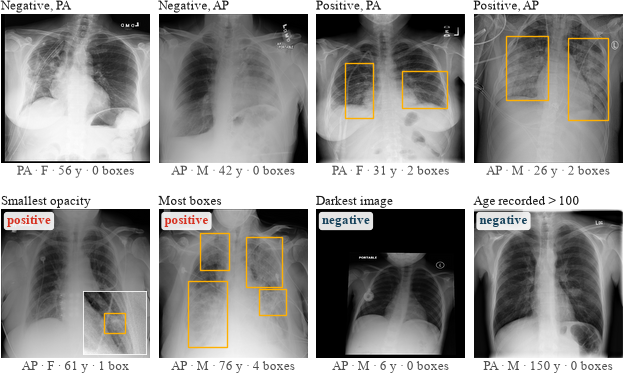

In [10]:
def load_dicom_image(path):
    """Read a DICOM file and return its pixels as float32 in [0, 1], with bright = dense (bone)."""
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)
    if ds.PhotometricInterpretation == "MONOCHROME1":     # MONOCHROME1 stores dense tissue as dark: invert
        img = img.max() - img
    return img / (2 ** int(ds.BitsStored) - 1)            # 8-bit data -> divide by 255

rng = np.random.default_rng(SPLIT_SEED)          # its own seeded generator, so the picks below are reproducible
total_box_area = exams.patientId.map(lambda pid: sum(w * h for (_, _, w, h) in BOXES.get(pid, [])))

def pick(mask):
    """Pick one exam at random (seeded) from the rows where `mask` is True."""
    return rng.choice(exams.index[mask])

examples = [
    ("Negative, PA", pick((exams.y == 0) & (exams.view == "PA") & (exams.age.between(30, 60)))),
    ("Negative, AP", pick((exams.y == 0) & (exams.view == "AP") & (exams.age.between(30, 60)))),
    ("Positive, PA", pick((exams.y == 1) & (exams.view == "PA") & (exams.n_boxes == 2))),
    ("Positive, AP", pick((exams.y == 1) & (exams.view == "AP") & (exams.n_boxes == 2))),
    ("Smallest opacity", total_box_area[exams.y == 1].idxmin()),
    ("Most boxes", exams.n_boxes.idxmax()),
    ("Darkest image", None),       # filled in below once intensities are known
    ("Age recorded > 100", pick(exams.age > 100)),
]

# The darkest image needs pixel data; we screen a seeded sample of 1,500 exams to keep this cell fast.
sample_idx = rng.choice(exams.index, size=1500, replace=False)
sample_means = {i: load_dicom_image(exams.path[i])[::8, ::8].mean() for i in sample_idx}   # every 8th pixel: enough for a mean
examples[6] = ("Darkest image", min(sample_means, key=sample_means.get))

fig, axes = plt.subplots(2, 4, figsize=figsize("full", aspect=0.62))
for k, (ax, (title, i)) in enumerate(zip(axes.flat, examples)):
    row = exams.loc[i]
    show_xray(ax, load_dicom_image(row.path)[::2, ::2], title=title,     # 512 x 512 is plenty for display
              note=f"{row.view} · {row.sex} · {row.age} y · {row.n_boxes} box{'es' if row.n_boxes != 1 else ''}",
              boxes=BOXES.get(row.patientId), box_scale=0.5,
              tag=("positive" if row.y else "negative") if k >= 4 else None,   # top-row titles already say it
              tag_color=POS if row.y else NEG)

# zoomed inset of the smallest annotated opacity: a square crop 3x the box's longer side, centred on the
# box and clipped to the 1024 x 1024 image; the box is redrawn in crop coordinates
row = exams.loc[examples[4][1]]
bx, by, bw_, bh = BOXES[row.patientId][0]        # box: top-left corner (x, y), width, height
half = 1.5 * max(bw_, bh)                        # half of the crop's side length
x0, y0 = int(max(bx + bw_ / 2 - half, 0)), int(max(by + bh / 2 - half, 0))
x1, y1 = int(min(x0 + 2 * half, 1024)), int(min(y0 + 2 * half, 1024))
inset = axes[1, 0].inset_axes([0.55, 0.03, 0.42, 0.42])
show_xray(inset, load_dicom_image(row.path)[y0:y1, x0:x1], boxes=[(bx - x0, by - y0, bw_, bh)])
for spine in inset.spines.values():
    spine.set_visible(True)
    spine.set_color("white")
save_and_show(fig, "A3_representative_images")

**Figure A3.** Eight exams chosen by the rules above. Gold rectangles are the annotated opacities; the inset zooms in on the smallest one.

In [11]:
example_table = pd.DataFrame([{
    "panel": title, "label": "positive" if exams.y[i] else "negative", "view": exams.view[i], "sex": exams.sex[i],
    "age": exams.age[i], "boxes": exams.n_boxes[i], "box area (% of image)": 100 * total_box_area[i] / 1024 ** 2,
    "mean brightness": load_dicom_image(exams.path[i]).mean(),
} for title, i in examples]).set_index("panel")
display(style_table(example_table, precision=3, caption="Facts behind each example"))
print(f"reference: median box area of positive exams = {100 * total_box_area[exams.y == 1].median() / 1024 ** 2:.1f}% of the image; "
      f"median mean brightness of the 1,500 screened exams = {np.median(list(sample_means.values())):.3f}")

,label,view,sex,age,boxes,box area (% of image),mean brightness
panel,,,,,,,
"Negative, PA",negative,PA,F,56,0,0.000,0.570
"Negative, AP",negative,AP,M,42,0,0.000,0.458
"Positive, PA",positive,PA,F,31,2,14.632,0.480
"Positive, AP",positive,AP,M,26,2,26.815,0.457
Smallest opacity,positive,AP,F,61,1,0.294,0.444
Most boxes,positive,AP,M,76,4,27.695,0.440
Darkest image,negative,AP,M,6,0,0.000,0.156
Age recorded > 100,negative,PA,M,150,0,0.000,0.413


reference: median box area of positive exams = 8.9% of the image; median mean brightness of the 1,500 screened exams = 0.469


**Why these examples.** The top row shows ordinary cases for each projection. The bottom row shows harder ones:
* **Smallest opacity:** a single box covering 0.294% of the image, while the median positive exam has 8.9% of its area inside boxes. At 224 px it is only a few pixels wide.
* **Most boxes:** four boxes covering 27.695% of the image, so widespread disease.
* **Darkest image:** mean brightness 0.156 against a median of 0.469. It is a 6-year-old child who fills only the centre of the frame.
* **Age above 100:** impossible header data, a reminder that metadata can be wrong.

Two of these exams are negative, and so is the top-left PA image, even though one of its lungs is clearly hazier than the other. This shows again that negative does not mean normal. Several images also carry burned-in text such as "PORTABLE", a possible shortcut we come back to in Section G.

---
## B. Leakage-safe splits

Many patients have several exams. If one exam of a patient is in training and another in the test set, the model can recognise the patient instead of the disease, and the test score becomes too optimistic. So we assign each NIH patient, with all their exams, to one split: 70% train, 15% validation and 15% test. Patients with and without a positive exam are shuffled separately, so each split gets a similar share of positives.

In [12]:
# One row per patient; any_positive_exam = 1 if at least one of the patient's exams is positive (max of y)
patients = exams.groupby("nih_patient_id").y.max().rename("any_positive_exam").reset_index()

rng = np.random.default_rng(SPLIT_SEED)
patient_split = {}
for _, stratum in patients.groupby("any_positive_exam"):
    ids = stratum.nih_patient_id.to_numpy()
    ids = ids[rng.permutation(len(ids))]                       # shuffle patients in this stratum
    n_train, n_val = round(0.70 * len(ids)), round(0.15 * len(ids))   # the rest (~15%) goes to test
    for pid in ids[:n_train]:
        patient_split[pid] = "train"
    for pid in ids[n_train:n_train + n_val]:
        patient_split[pid] = "val"
    for pid in ids[n_train + n_val:]:
        patient_split[pid] = "test"

exams["split"] = exams.nih_patient_id.map(patient_split)       # every exam inherits its patient's split
SPLITS = ["train", "val", "test"]

### B.1 Check that no patient is in two splits

In [13]:
patient_ids = {s: set(exams.loc[exams.split == s, "nih_patient_id"]) for s in SPLITS}
exam_ids = {s: set(exams.loc[exams.split == s, "patientId"]) for s in SPLITS}

# no source patient occurs in more than one split ...
assert patient_ids["train"].isdisjoint(patient_ids["val"]), "patient leakage train <-> val"
assert patient_ids["train"].isdisjoint(patient_ids["test"]), "patient leakage train <-> test"
assert patient_ids["val"].isdisjoint(patient_ids["test"]), "patient leakage val <-> test"
# ... every patient and every exam is used exactly once
assert sum(len(v) for v in patient_ids.values()) == n_patients
assert sum(len(v) for v in exam_ids.values()) == n_exams
assert set.union(*exam_ids.values()) == set(exams.patientId)

For comparison only: how many test exams would share a patient with training if we had split by exam instead of by patient?

In [14]:
naive_split = rng.choice(SPLITS, size=n_exams, p=[0.70, 0.15, 0.15])
naive_train_patients = set(exams.nih_patient_id[naive_split == "train"])
naive_test = exams[naive_split == "test"]
leaked = naive_test.nih_patient_id.isin(naive_train_patients)
print(f"naive exam-level split: {leaked.sum():,} of {len(naive_test):,} test exams ({leaked.mean():.1%}) "
      "belong to a patient who also has exams in training")
print("patient-level split   : 0 test exams belong to a training patient (asserted above)")

naive exam-level split: 2,569 of 3,821 test exams (67.2%) belong to a patient who also has exams in training
patient-level split   : 0 test exams belong to a training patient (asserted above)


### B.2 Size and positive share of each split

In [15]:
split_table = (exams.groupby("split")
               .agg(patients=("nih_patient_id", "nunique"), exams=("patientId", "size"),
                    positives=("y", "sum"), prevalence=("y", "mean"))
               .reindex(SPLITS))
split_table["share of exams"] = split_table.exams / n_exams
display(style_table(split_table, precision=3, caption="Patient-grouped splits"))

,patients,exams,positives,prevalence,share of exams
split,,,,,
train,"7,820","17,920","3,934",0.220,0.698
val,"1,676","3,987",910,0.228,0.155
test,"1,675","3,777",815,0.216,0.147


PASS B4_splits: 0 errors, 0 warnings, 1 taste notes -> figures/_preview/B4_splits.png
  [taste] aspect: panel aspect 0.18; lines read best around 0.5-0.8


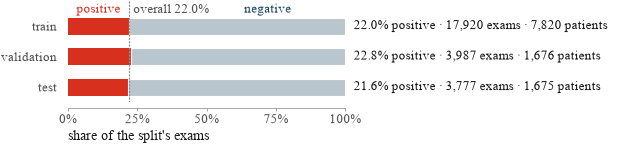

In [16]:
fig, ax = plt.subplots(figsize=figsize("full", aspect=0.24))
order = ["test", "val", "train"]                              # train on top
for i, split in enumerate(order):
    r = split_table.loc[split]
    ax.barh(i, r.prevalence, height=0.56, color=POS)                           # positives first: shares line up at 0
    ax.barh(i, 1 - r.prevalence, left=r.prevalence, height=0.56, color=tint(NEG, 0.3), edgecolor="white", linewidth=0.8)  # context: pale
    ax.text(1.03, i, f"{r.prevalence:.1%} positive · {int(r.exams):,} exams · {int(r.patients):,} patients",
            va="center", fontsize=TICK_PT)
ax.axvline(exams.y.mean(), color=NEUTRALS[1], lw=0.9, ls=":")
ax.text(exams.y.mean() + 0.015, 2.34, f"overall {exams.y.mean():.1%}", ha="left", va="bottom", fontsize=TICK_PT, color=MUTED)
ax.text(split_table.loc["train", "prevalence"] / 2, 2.34, "positive", ha="center", va="bottom", fontsize=TICK_PT, color=text_color(POS))
ax.text(0.72, 2.34, "negative", ha="center", va="bottom", fontsize=TICK_PT, color=text_color(NEG))
ax.set_yticks(range(3), ["test", "validation", "train"])
ax.set_xlabel("share of the split's exams", loc="left")
finish(ax, x="pct1", categorical="y")
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xlim(0, 2.0)
ax.spines["bottom"].set_bounds(0, 1)
ax.set_ylim(-0.5, 2.85)
save_and_show(fig, "B4_splits")

**Figure B4.** Every split has a positive share between 21.6% and 22.8%.

### B.3 Lock the test set away
From here until Section F we only use the training and validation splits, and every choice (normalisation, weight decay, learning rate, epochs, thresholds) is made on them. `test_rows` is just a list of row numbers, and F.1 checks that no earlier cell used it.

In [17]:
# Row numbers (positions in `exams`) of each split; the image cache in C.1 uses the same row order.
train_rows = np.flatnonzero(exams.split == "train")
val_rows = np.flatnonzero(exams.split == "val")
test_rows = np.flatnonzero(exams.split == "test")      # not touched again until Section F
TEST_SET_OPENED = False                                # set to True in Section F, checked there

y_train = exams.y.to_numpy()[train_rows]
y_val = exams.y.to_numpy()[val_rows]
print(f"train {len(train_rows):,} | val {len(val_rows):,} | test {len(test_rows):,} (locked)")

train 17,920 | val 3,987 | test 3,777 (locked)


### B.4 A leak that patient grouping cannot prevent
**A leakage route that patient grouping does not prevent: site leakage.** In a dataset from several hospitals, each site has its own scanners, image markers and pneumonia rate. A patient-level split still puts every site in both training and test, so a model can learn that "images from site X are often positive" and still score well.

How to test for it:
1. Train a small model to predict the site from the image. If it works, the images carry a site fingerprint.
2. Evaluate with leave-one-site-out splits. A clear drop on unseen sites means the model relied on the site.
3. Report AUROC within each site.

Our data come from one hospital and have no site field. The closest thing is the projection (AP bedside vs PA department), which we look at in G.2.

---
## C. Preprocessing, augmentation and class imbalance

### C.1 From DICOM to tensor
Every image goes through the same steps:
1. Decode the 1024 × 1024 8-bit pixel array. All files are `MONOCHROME2`, so no inversion is needed.
2. Divide by 255 to get values in [0, 1].
3. Resize to 224 × 224, the ImageNet resolution, with area averaging to avoid aliasing. The median opacity box is 219 × 304 px, which is still 47.9 × 66.5 px after resizing.
4. Cache the result as `uint8`, so the DICOMs are decoded only once.
5. When an image is used, standardise it with the mean and SD of the training pixels.

In [18]:
def preprocess_dicom(path, size=IMG_SIZE):
    """DICOM file -> size x size uint8 array (steps 1-4 of the table above)."""
    img = load_dicom_image(path)                                   # float32 in [0, 1], bright = dense
    h, w = img.shape
    if h != w:                                                     # pad to square (never needed here, kept for safety)
        side = max(h, w)
        img = np.pad(img, ((0, side - h), (0, side - w)))
    img_8bit = Image.fromarray(np.round(img * 255).astype(np.uint8))
    return np.asarray(img_8bit.resize((size, size), Image.Resampling.BOX))

image_cache = CACHE_DIR / f"images_{IMG_SIZE}.npy"
if image_cache.exists():
    IMAGES = np.load(image_cache)
    print(f"loaded cached images {IMAGES.shape} {IMAGES.dtype} from {image_cache}")
else:
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as pool:              # rows follow the order of `exams`
        IMAGES = np.stack(list(pool.map(preprocess_dicom, exams.path)))
    np.save(image_cache, IMAGES)
    print(f"preprocessed {len(IMAGES):,} DICOMs in {time.time() - t0:.0f} s -> {image_cache} "
          f"({IMAGES.nbytes / 1e9:.2f} GB)")
assert IMAGES.shape == (n_exams, IMG_SIZE, IMG_SIZE) and IMAGES.dtype == np.uint8

box_sizes = labels_raw.loc[labels_raw.Target == 1, ["width", "height"]]          # all annotated boxes
w_med, h_med = box_sizes.width.median(), box_sizes.height.median()
print(f"median annotated box: {w_med:.0f} x {h_med:.0f} px at 1024 px -> "
      f"{w_med * IMG_SIZE / 1024:.1f} x {h_med * IMG_SIZE / 1024:.1f} px at {IMG_SIZE} px")

loaded cached images (25684, 224, 224) uint8 from data/cache/images_224.npy
median annotated box: 219 x 304 px at 1024 px -> 47.9 x 66.5 px at 224 px


The mean and SD are computed from a histogram of all training pixels.

In [19]:
pixel_histogram = np.zeros(256, dtype=np.int64)
for start in range(0, len(train_rows), 1000):
    pixel_histogram += np.bincount(IMAGES[train_rows[start:start + 1000]].ravel(), minlength=256)

levels = np.arange(256) / 255.0                                  # grey level of each histogram bin, in [0, 1]
# mean = sum(count x level) / number of pixels; SD = sqrt(sum(count x (level - mean)^2) / number of pixels)
PIXEL_MEAN = float((pixel_histogram * levels).sum() / pixel_histogram.sum())
PIXEL_STD = float(np.sqrt((pixel_histogram * (levels - PIXEL_MEAN) ** 2).sum() / pixel_histogram.sum()))
print(f"training-pixel mean μ = {PIXEL_MEAN:.4f}, standard deviation σ = {PIXEL_STD:.4f} "
      f"(from {pixel_histogram.sum():,} pixels of {len(train_rows):,} training images)")

training-pixel mean μ = 0.4902, standard deviation σ = 0.2469 (from 899,153,920 pixels of 17,920 training images)


**Preprocessing summary.** Decode, divide by 255, resize to 224 × 224, cache, then standardise with the training statistics (μ = 0.4902, σ = 0.2469). Validation and test images use the same statistics and are never augmented.

### C.2 Training-only augmentation
Each transformation imitates variation that really happens between chest X-rays:

| transform | range | why |
|---|---|---|
| rotation | ± 7° | patients are rarely perfectly straight |
| shift | ± 5% | the chest is not always centred |
| scale | 0.92–1.08 | body size; bedside AP images are magnified |
| brightness / contrast | ± 10% | exposure differs between machines |

The ranges are small, so the lungs stay in the image. Pixels that move in from outside are filled with black, like the image border.

In [20]:
# Each call draws new random parameters within these ranges (see the table above).
train_augment = T.Compose([
    T.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.92, 1.08), fill=0.0),   # rotate, shift, zoom
    T.ColorJitter(brightness=0.10, contrast=0.10),                                     # exposure changes
])

class CXRDataset(torch.utils.data.Dataset):
    """(image, label) pairs from uint8 images (N x 224 x 224), optionally augmented, then standardised."""

    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        x = torch.from_numpy(self.images[i]).float().div(255).unsqueeze(0)   # 1 x 224 x 224, values in [0, 1]
        if self.augment:
            x = train_augment(x)                                             # random, different every epoch
        x = (x - PIXEL_MEAN) / PIXEL_STD                                      # standardise
        return x, self.labels[i]

train_ds = CXRDataset(IMAGES[train_rows], y_train, augment=True)
val_ds = CXRDataset(IMAGES[val_rows], y_val, augment=False)
print(f"train {len(train_ds):,} (augmented) | val {len(val_ds):,} (not augmented)")

train 17,920 (augmented) | val 3,987 (not augmented)


PASS C2_augmentation_panel: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/C2_augmentation_panel.png


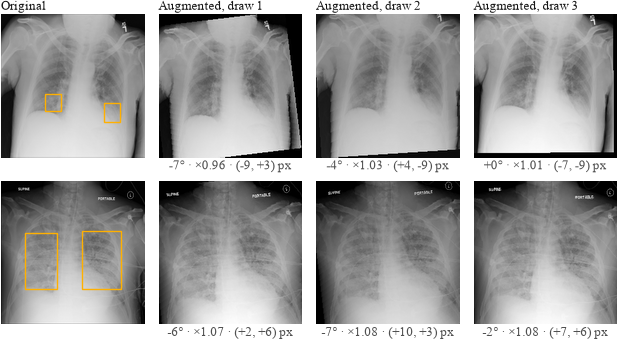

In [21]:
set_seed(SPLIT_SEED)                                           # fixes the random augmentation draws shown below
positive_train = np.flatnonzero(y_train == 1)                  # positions of the positive training exams
demo_rows = [train_rows[i] for i in np.random.default_rng(SPLIT_SEED).choice(positive_train, 2, replace=False)]

affine, jitter = train_augment.transforms                      # the two transforms used in training
n_draws = 3
fig, axes = plt.subplots(2, n_draws + 1, figsize=figsize("full", aspect=0.55))
draws = []
for r, row in enumerate(demo_rows):
    original = torch.from_numpy(IMAGES[row]).float().div(255).unsqueeze(0)
    show_xray(axes[r, 0], original[0], boxes=BOXES.get(exams.patientId[row]), box_scale=IMG_SIZE / 1024,
              title="Original" if r == 0 else None)
    for c in range(1, n_draws + 1):
        # same random draw as train_augment, but keeping the parameters so we can print them
        pa, pj = affine.make_params([original]), jitter.make_params([original])
        augmented = jitter.transform(affine.transform(original, pa), pj)
        dx, dy = pa["translate"]
        show_xray(axes[r, c], augmented[0], title=f"Augmented, draw {c}" if r == 0 else None,
                  note=f"{round(pa['angle']):+d}° · ×{pa['scale']:.2f} · ({dx:+d}, {dy:+d}) px")
        draws.append({"image": r + 1, "draw": c, "rotation (°)": pa["angle"], "scale": pa["scale"],
                      "shift x (px)": dx, "shift y (px)": dy, "brightness ×": pj["brightness_factor"],
                      "contrast ×": pj["contrast_factor"]})
    for ax in axes[r]:
        ax.images[0].set_clim(0, 1)                    # identical grey scale in every panel
display(style_table(pd.DataFrame(draws).set_index(["image", "draw"]), precision=2,
                    caption="Sampled augmentation parameters of the draws shown below"))
save_and_show(fig, "C2_augmentation_panel")

**Figure C2.** Three random augmentations of two positive training images, with the sampled rotation, scale and shift under each.

**Why these are safe.** Each change is small, matches real variation between X-rays, and cannot remove an opacity, so the label stays correct. The black corners left by rotation (top row, draw 1) look like the black borders real images already have.

**What we did not use.**
* **Horizontal flip.** The chest is not symmetric: the heart and stomach are on the left. A flipped image shows anatomy that almost never occurs, mirrors the side markers, and the side of an opacity matters clinically.
* **Vertical flip or large rotations.** Upside-down or sideways chests never occur.
* **Random erasing or aggressive crops.** They could remove the only opacity and turn a positive image into a negative one.
* **Strong contrast or blur changes.** They could hide faint opacities.

### C.3 Class imbalance: weighted loss
Only 22% of training exams are positive, so a model can reach 78% accuracy by always saying "negative". We use `nn.BCEWithLogitsLoss` with `pos_weight` = N_neg / N_pos, which scales up the loss of every positive exam so that both classes count equally:

$$\mathcal{L} = -\frac{1}{N}\sum_i \Big[\, w_+ \, y_i \log p_i + (1 - y_i) \log (1 - p_i) \Big], \qquad w_+ = \frac{N_{neg}}{N_{pos}}.$$

Unlike oversampling, every image is still used once per epoch. In E.7 we train the same CNN without the weight to see what it changes.

In [22]:
n_pos_train, n_neg_train = int(y_train.sum()), int((1 - y_train).sum())
POS_WEIGHT = n_neg_train / n_pos_train             # ≈ 3.6: each positive counts like ~3.6 negatives in the loss
print(f"training split: {n_neg_train:,} negatives / {n_pos_train:,} positives -> pos_weight = {POS_WEIGHT:.3f}")

training split: 13,986 negatives / 3,934 positives -> pos_weight = 3.555


---
## D. Baselines

### D.0 Metrics used for every model
All models are scored with the same two functions: ranking metrics (AUROC, AUPRC) and confusion-matrix metrics at a given threshold.

In [23]:
def ranking_metrics(y, p):
    """Threshold-free metrics. AUPRC is estimated by average precision."""
    return {"AUROC": roc_auc_score(y, p), "AUPRC": average_precision_score(y, p)}

def metrics_at_threshold(y, p, threshold):
    """Confusion-matrix metrics when an exam is called positive if p >= threshold."""
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "accuracy": (tp + tn) / len(y),
        "sensitivity": tp / (tp + fn),                              # recall, true-positive rate
        "specificity": tn / (tn + fp),                              # true-negative rate
        "precision": tp / (tp + fp) if tp + fp > 0 else np.nan,     # PPV; undefined if nothing is called positive
        "F1": 2 * tp / (2 * tp + fp + fn),                          # harmonic mean of precision and sensitivity
    }

### D.1 Trivial baseline
The majority class in training is negative, so this model always predicts negative. It gives every exam the same score, so its AUROC is 0.5 and its AUPRC equals the prevalence.

In [24]:
MAJORITY_CLASS = int(y_train.mean() > 0.5)                       # 0 = negative
trivial_val_p = np.full(len(y_val), float(MAJORITY_CLASS))        # constant score for every exam

trivial_val = {**ranking_metrics(y_val, trivial_val_p), **metrics_at_threshold(y_val, trivial_val_p, 0.5)}
display(style_table(pd.DataFrame([trivial_val], index=["trivial (validation)"])
                    [["AUROC", "AUPRC", "accuracy", "sensitivity", "specificity", "precision", "F1"]],
                    caption="Trivial majority-class baseline on the validation split (test results in Section F)"))

,AUROC,AUPRC,accuracy,sensitivity,specificity,precision,F1
trivial (validation),0.500,0.228,0.772,0.000,1.000,–,0.000


### D.2 Logistic regression on 15 image features
For each 224 × 224 image (scaled to [0, 1]) we compute the mean, the standard deviation, the 5th, 25th, 50th, 75th and 95th percentiles, and the fraction of pixels in 8 equal brightness bins.

These describe how bright the image is, not where anything is. Opacities make the lungs brighter, but so do exposure and body size, so this is a weak but fair baseline. The features are standardised with the training mean and SD, and the model is one `nn.Linear(15, 1)` layer trained with the same weighted loss as the CNN (full-batch Adam). We pick the weight decay by validation AUROC.

In [25]:
FEATURE_NAMES = (["mean", "std", "p05", "p25", "p50", "p75", "p95"]
                 + [f"bin {k} [{k / 8:.3f}, {(k + 1) / 8:.3f})" for k in range(8)])

def image_summary_features(images_uint8, chunk=2000):
    """15 global intensity features per image (see list above)."""
    out = []
    for start in range(0, len(images_uint8), chunk):            # chunks keep memory use small
        x = images_uint8[start:start + chunk].reshape(-1, IMG_SIZE * IMG_SIZE).astype(np.float32) / 255
        stats = [x.mean(1), x.std(1), *np.percentile(x, [5, 25, 50, 75, 95], axis=1)]
        bin_index = np.minimum((x * 8).astype(int), 7)           # 0..7; the value 1.0 goes to the last bin
        bins = [(bin_index == k).mean(1) for k in range(8)]
        out.append(np.stack(stats + bins, axis=1))
    return np.concatenate(out).astype(np.float32)

feat_train = image_summary_features(IMAGES[train_rows])
feat_val = image_summary_features(IMAGES[val_rows])
FEAT_MEAN, FEAT_STD = feat_train.mean(0), feat_train.std(0) + 1e-8     # training statistics only
standardise = lambda f: (f - FEAT_MEAN) / FEAT_STD                     # applied to every split with the TRAIN mean/SD
X_train_feat, X_val_feat = standardise(feat_train), standardise(feat_val)
print(f"feature matrix: train {X_train_feat.shape}, val {X_val_feat.shape}")

def train_logistic(X, y, weight_decay, seed, steps=500, lr=0.05):
    """Full-batch logistic regression with nn.Linear and the weighted BCE loss."""
    set_seed(seed)
    model = nn.Linear(X.shape[1], 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT))
    X, y = torch.from_numpy(X), torch.from_numpy(y.astype(np.float32))
    for _ in range(steps):                                          # each step uses ALL training exams (full batch)
        optimizer.zero_grad()
        loss = loss_fn(model(X).squeeze(1), y)
        loss.backward()
        optimizer.step()
    return model

def predict_logistic(model, X):
    """Probabilities = sigmoid of the model's logits."""
    with torch.no_grad():
        return torch.sigmoid(model(torch.from_numpy(X)).squeeze(1)).numpy()

# Setting selection on the validation split: train with each weight decay (seed 0), score on validation
WEIGHT_DECAYS = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
wd_search = pd.DataFrame([
    {"weight_decay": wd, "val AUROC": roc_auc_score(y_val, predict_logistic(train_logistic(X_train_feat, y_train, wd, seed=0), X_val_feat))}
    for wd in WEIGHT_DECAYS])
BEST_WD = float(wd_search.loc[wd_search["val AUROC"].idxmax(), "weight_decay"])
display(style_table(wd_search, precision=4, caption=f"Weight-decay search (selected: {BEST_WD:g})"))

# Final baseline: the selected setting, retrained with each training seed
logistic_models = {seed: train_logistic(X_train_feat, y_train, BEST_WD, seed) for seed in TRAIN_SEEDS}
logistic_val_p = {seed: predict_logistic(m, X_val_feat) for seed, m in logistic_models.items()}
logistic_val_auroc = [roc_auc_score(y_val, p) for p in logistic_val_p.values()]
print(f"logistic baseline, val AUROC over seeds {TRAIN_SEEDS}: "
      f"{np.mean(logistic_val_auroc):.4f} ± {np.std(logistic_val_auroc, ddof=1):.4f}")

feature matrix: train (17920, 15), val (3987, 15)


,weight_decay,val AUROC
0,0.0000,0.7126
1,0.0001,0.7127
2,0.0010,0.7135
3,0.0100,0.7145
4,0.1000,0.7064
5,1.0000,0.6769


logistic baseline, val AUROC over seeds [0, 1, 2]: 0.7145 ± 0.0000


PASS D2_logistic_baseline: 0 errors, 0 warnings, 1 taste notes -> figures/_preview/D2_logistic_baseline.png
  [taste] ticks: 15 major ticks; 3-6 is calmer (finish(ax) sets this)


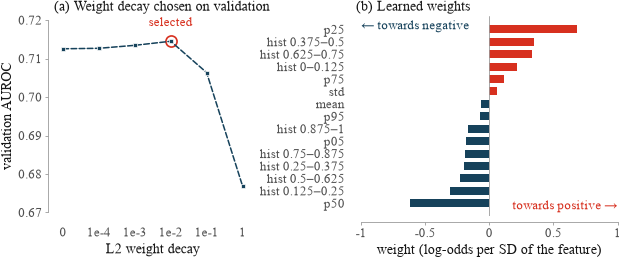

correlation of the p25 and p50 features on the training images: r = 0.851


In [26]:
coefs = logistic_models[TRAIN_SEEDS[0]].weight.detach().numpy()[0]
order = np.argsort(coefs)

fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.42), width_ratios=[1, 1.35])

ax = axes[0]                                                   # (a) weight-decay search
s = method_style("logistic")
x_pos = np.arange(len(WEIGHT_DECAYS))
ax.plot(x_pos, wd_search["val AUROC"], **s["plot"], **s["markers"])
best_i = WEIGHT_DECAYS.index(BEST_WD)
ax.plot(best_i, wd_search["val AUROC"][best_i], "o", ms=8, mfc="none", mec=RED, mew=1.2, label="_selected")
ax.set_xticks(x_pos, ["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
ax.set_xlabel("L2 weight decay")
ax.set_ylabel("validation AUROC")
ax.set_title("(a) Weight decay chosen on validation")
finish(ax, categorical="x")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.annotate("selected", (best_i, wd_search["val AUROC"][best_i]), xytext=(0, 9), textcoords="offset points",
            ha="center", va="bottom", fontsize=TICK_PT, color=text_color(RED))

ax = axes[1]                                                   # (b) learned weights
short_names = ["mean", "std", "p05", "p25", "p50", "p75", "p95"] + [f"hist {k / 8:g}–{(k + 1) / 8:g}" for k in range(8)]
ax.barh(np.arange(len(coefs)), coefs[order], height=0.64, color=[POS if c > 0 else NEG for c in coefs[order]])
ax.set_yticks(np.arange(len(coefs)), [short_names[i] for i in order])
ax.axvline(0, color=RULE, lw=0.6)
ax.set_xlabel("weight (log-odds per SD of the feature)")
ax.set_title("(b) Learned weights")
finish(ax, categorical="y")
ax.text(0.02, 0.98, "← towards negative", transform=ax.transAxes, ha="left", va="top", fontsize=TICK_PT, color=text_color(NEG))

ax.text(0.98, 0.02, "towards positive →", transform=ax.transAxes, ha="right", va="bottom", fontsize=TICK_PT, color=text_color(POS))

save_and_show(fig, "D2_logistic_baseline")
r_p25_p50 = np.corrcoef(feat_train[:, 3], feat_train[:, 4])[0, 1]          # columns 3 and 4 are p25 and p50
print(f"correlation of the p25 and p50 features on the training images: r = {r_p25_p50:.3f}")

**Figure D2.** (a) Weight decay up to 0.01 hardly matters and larger values underfit. (b) The learned weights; p25 and p50 get large opposite weights because they are strongly correlated (r = 0.851).

**Reading the baseline.** Each weight is the change in log-odds of "opacity" for a one-SD increase in that feature, with the others held fixed. The features are strongly correlated, so opposite weights on similar features (such as p25 and p50) partly cancel and should not be read one by one. Weight decay 0.01 gave the best validation AUROC. The problem is convex and trained on the full batch, so every seed gives the same model. It is tested once, in Section F, together with the other models.

---
## E. Pretrained CNN: ResNet-18

### E.1 Adapting ResNet-18
We use torchvision's ResNet-18 with ImageNet weights (`IMAGENET1K_V1`). Two parts need changing:
1. **Input channels.** The first layer `conv1` expects RGB images (weights 64 × 3 × 7 × 7). We replace it with a 1-channel layer whose weights are the sum of the three RGB kernels (64 × 1 × 7 × 7). Convolution is linear, so this gives exactly the same output as feeding the grey image copied into three channels, and no pretrained information is lost.
2. **Output head.** The 1,000-class layer `fc` is replaced by a new `nn.Linear(512, 1)` that outputs one logit. `sigmoid(logit)` is the probability of opacity, and the loss works directly on the logit.

In [27]:
def build_resnet18_1ch():
    """ImageNet ResNet-18 with a 1-channel first convolution and a single-logit head."""
    model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

    rgb_weight = model.conv1.weight.detach()                     # 64 x 3 x 7 x 7
    # same as the original conv1, but with 1 input channel
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1.weight.data = rgb_weight.sum(dim=1, keepdim=True)  # 64 x 1 x 7 x 7

    model.fc = nn.Linear(model.fc.in_features, 1)                 # 512 -> 1 logit, new random weights
    return model

# Check the equivalence claimed above on a random grey image.
reference = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
adapted = build_resnet18_1ch()
grey = torch.randn(2, 1, IMG_SIZE, IMG_SIZE)                   # two random 1-channel "images"
with torch.no_grad():
    # original conv1 on a 3-channel copy vs adapted conv1 on the 1-channel image
    same = torch.allclose(reference.conv1(grey.repeat(1, 3, 1, 1)), adapted.conv1(grey), atol=1e-5)
print(f"conv1: {tuple(reference.conv1.weight.shape)} -> {tuple(adapted.conv1.weight.shape)}; "
      f"identical output to the RGB conv on a replicated grey image: {same}")
print(f"head : {reference.fc} -> {adapted.fc}")
print(f"parameters: {sum(p.numel() for p in adapted.parameters()):,} in total")

del reference, adapted

conv1: (64, 3, 7, 7) -> (64, 1, 7, 7); identical output to the RGB conv on a replicated grey image: True
head : Linear(in_features=512, out_features=1000, bias=True) -> Linear(in_features=512, out_features=1, bias=True)
parameters: 11,170,753 in total


The check above confirms that the new `conv1` gives the same output as the original layer on a three-channel copy of the image.

### E.2 Two-stage training
* **Stage 1 (fixed feature extractor):** all pretrained weights are frozen and only the new head is trained.
* **Stage 2 (fine-tuning):** the last block, `layer4` (8.4 M parameters), is unfrozen and trained together with the head at a smaller learning rate. `conv1` to `layer3` stay frozen.

BatchNorm layers in frozen blocks stay in evaluation mode, so they keep their ImageNet statistics. After every epoch we compute the validation AUROC and keep the best epoch of each stage: stage 1 gives the "frozen features" model and stage 2 the fine-tuned model, which is our main (headline) model.

In [28]:
CNN_CONFIG = {
    "batch_size": 64,
    "stage1_epochs": 4, "stage1_lr": 1e-3,      # head only
    "stage2_epochs": 8, "stage2_lr": None,      # layer4 + head, cosine-decayed to 0; lr chosen in E.3
    "weight_decay": 1e-4,                       # AdamW
}
print(CNN_CONFIG)
print(f"trainable in stage 2: layer4 has {sum(p.numel() for p in build_resnet18_1ch().layer4.parameters()):,} parameters")

val_loader = torch.utils.data.DataLoader(val_ds, batch_size=256, shuffle=False)   # fixed order; larger batches are fine without gradients

def set_trainable(model, block_names):
    """Freeze every parameter, then unfreeze the parameters of the named blocks."""
    for p in model.parameters():
        p.requires_grad = False
    for name in block_names:
        for p in getattr(model, name).parameters():
            p.requires_grad = True

def run_epoch(model, loader, loss_fn, optimizer=None, trainable_blocks=()):
    """One pass over `loader`. Updates the weights if an optimizer is given; otherwise only evaluates.
    Returns (mean loss, predicted probabilities)."""
    training = optimizer is not None
    model.eval()                                    # frozen BatchNorm layers keep their ImageNet statistics
    if training:
        for name in trainable_blocks:
            getattr(model, name).train()            # only the blocks being trained update BatchNorm statistics
    total_loss, probs = torch.zeros((), device=DEVICE), []
    with torch.set_grad_enabled(training):          # gradients only when training (evaluation needs none)
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x).squeeze(1)            # shape (batch, 1) -> (batch,)
            loss = loss_fn(logits, y)               # mean loss over the batch
            if training:
                optimizer.zero_grad()               # clear the gradients of the previous batch
                loss.backward()                     # backpropagate: gradients of the trainable weights
                optimizer.step()                    # one AdamW update
            total_loss += loss.detach() * len(y)    # batch mean x batch size = batch sum
            probs.append(torch.sigmoid(logits).detach().cpu())   # logit -> probability
    return total_loss.item() / len(loader.dataset), torch.cat(probs).numpy()

def predict(model, dataset, batch_size=256):
    """Predicted probabilities for every image of `dataset` (no augmentation, no gradients)."""
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        return torch.cat([torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu() for x, _ in loader]).numpy()

def train_cnn(seed, weighted_loss=True, cfg=CNN_CONFIG):
    """Train one CNN (stage 1 + stage 2) with the given seed. Returns (stage-1 model, stage-2 model, history).
    A finished run in RUN_DIR is loaded instead of retrained only if RETRAIN is False AND its saved configuration
    (every setting that affects training) equals the current one; any change triggers retraining."""
    name = f"resnet18_{'weighted' if weighted_loss else 'unweighted'}_lr{cfg['stage2_lr']:g}_seed{seed}"
    run_path = RUN_DIR / name
    models = {1: build_resnet18_1ch().to(DEVICE), 2: build_resnet18_1ch().to(DEVICE)}
    run_config = {**cfg, "seed": seed, "pos_weight": POS_WEIGHT if weighted_loss else 1.0,
                  "pixel_mean": PIXEL_MEAN, "pixel_std": PIXEL_STD, "augmentation": repr(train_augment),
                  "n_train": len(train_ds), "n_val": len(val_ds)}
    run_config = json.loads(json.dumps(run_config))                  # plain JSON values, comparable with the saved copy
    config_file = run_path / "config.json"
    saved_config = json.loads(config_file.read_text()) if config_file.exists() else None

    if not RETRAIN and (run_path / "stage2_best.pt").exists() and saved_config == run_config:
        history = json.loads((run_path / "history.json").read_text())
        for stage in (1, 2):
            models[stage].load_state_dict(torch.load(run_path / f"stage{stage}_best.pt", map_location=DEVICE))
        print(f"[{name}] loaded from {run_path} (trained earlier with this code; set RETRAIN=True to retrain)")
        for h in history:
            print(f"  stage {h['stage']} epoch {h['epoch']:>2} | train loss {h['train_loss']:.4f} | "
                  f"val loss {h['val_loss']:.4f} | val AUROC {h['val_auroc']:.4f} | {h['seconds']:.0f}s")
        return models[1].eval(), models[2].eval(), history

    set_seed(seed)                                                   # controls head init, batch order, augmentation
    model = build_resnet18_1ch().to(DEVICE)
    pos_weight = torch.tensor(POS_WEIGHT if weighted_loss else 1.0, device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # reshuffled every epoch; the generator ties the batch order to the seed
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                                               generator=torch.Generator().manual_seed(seed))
    history, best = [], {}

    def fit(stage, blocks, epochs, lr):
        """Train the named blocks for `epochs` epochs; remember the epoch with the best validation AUROC."""
        set_trainable(model, blocks)
        optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],   # trainable weights only
                                      lr=lr, weight_decay=cfg["weight_decay"])
        # stage 2: cosine decay of the learning rate to 0
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) if stage == 2 else None
        best[stage] = {"auroc": -1.0}
        for _ in range(epochs):
            t0 = time.time()
            train_loss, _ = run_epoch(model, train_loader, loss_fn, optimizer, blocks)
            val_loss, val_p = run_epoch(model, val_loader, loss_fn)
            if scheduler:
                scheduler.step()
            auroc = roc_auc_score(y_val, val_p)
            history.append({"stage": stage, "epoch": len(history) + 1, "train_loss": train_loss,
                            "val_loss": val_loss, "val_auroc": auroc, "seconds": time.time() - t0})
            print(f"  stage {stage} epoch {len(history):>2} | train loss {train_loss:.4f} | "
                  f"val loss {val_loss:.4f} | val AUROC {auroc:.4f} | {time.time() - t0:.0f}s")
            if auroc > best[stage]["auroc"]:                         # new best epoch of this stage
                best[stage] = {"auroc": auroc, "epoch": len(history),
                               "state": copy.deepcopy(model.state_dict())}   # a copy: later epochs change the weights

    if (run_path / "stage2_best.pt").exists() and not RETRAIN:
        print(f"[{name}] saved run has a different configuration -> retraining")
    print(f"[{name}] training on {DEVICE}")
    fit(stage=1, blocks=["fc"], epochs=cfg["stage1_epochs"], lr=cfg["stage1_lr"])
    model.load_state_dict(best[1]["state"])                          # stage 2 starts from the best stage-1 head
    fit(stage=2, blocks=["layer4", "fc"], epochs=cfg["stage2_epochs"], lr=cfg["stage2_lr"])

    run_path.mkdir(parents=True, exist_ok=True)
    for stage in (1, 2):
        torch.save(best[stage]["state"], run_path / f"stage{stage}_best.pt")
        models[stage].load_state_dict(best[stage]["state"])
    (run_path / "history.json").write_text(json.dumps(history, indent=1))
    config_file.write_text(json.dumps(run_config, indent=1))          # lets a later run check it is still valid
    print(f"[{name}] best val AUROC: stage 1 {best[1]['auroc']:.4f} (epoch {best[1]['epoch']}), "
          f"stage 2 {best[2]['auroc']:.4f} (epoch {best[2]['epoch']})")
    return models[1].eval(), models[2].eval(), history

{'batch_size': 64, 'stage1_epochs': 4, 'stage1_lr': 0.001, 'stage2_epochs': 8, 'stage2_lr': None, 'weight_decay': 0.0001}
trainable in stage 2: layer4 has 8,393,728 parameters


### E.3 Choosing the fine-tuning learning rate
With 8.4 M trainable parameters and 17,920 training images, the learning rate controls how fast the model starts to memorise the training set. We try three values with seed 0 and keep the one with the best validation AUROC.

[resnet18_weighted_lr0.0001_seed0] training on mps


  stage 1 epoch  1 | train loss 0.8794 | val loss 0.8327 | val AUROC 0.8173 | 37s


  stage 1 epoch  2 | train loss 0.8075 | val loss 0.8237 | val AUROC 0.8264 | 37s


  stage 1 epoch  3 | train loss 0.7961 | val loss 0.8083 | val AUROC 0.8291 | 35s


  stage 1 epoch  4 | train loss 0.7904 | val loss 0.8111 | val AUROC 0.8316 | 37s


...

  stage 2 epoch 10 | train loss 0.6769 | val loss 0.7551 | val AUROC 0.8551 | 39s


  stage 2 epoch 11 | train loss 0.6659 | val loss 0.7552 | val AUROC 0.8550 | 40s


  stage 2 epoch 12 | train loss 0.6631 | val loss 0.7554 | val AUROC 0.8551 | 40s
[resnet18_weighted_lr1e-05_seed0] best val AUROC: stage 1 0.8316 (epoch 4), stage 2 0.8551 (epoch 10)


,best val AUROC,best epoch,val loss at last epoch,train loss at last epoch
stage-2 learning rate,,,,
0.000100,0.8583,7,0.9246,0.3810
0.000030,0.8577,10,0.7728,0.5527
0.000010,0.8551,10,0.7554,0.6631


PASS E2_lr_selection: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/E2_lr_selection.png


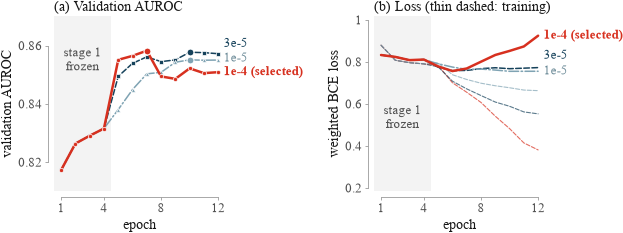

In [29]:
LR_GRID = [1e-4, 3e-5, 1e-5]
lr_runs = {lr: train_cnn(0, weighted_loss=True, cfg={**CNN_CONFIG, "stage2_lr": lr}) for lr in LR_GRID}

lr_table = pd.DataFrame([{
    "stage-2 learning rate": lr,
    "best val AUROC": max(h["val_auroc"] for h in hist_ if h["stage"] == 2),
    "best epoch": max((h for h in hist_ if h["stage"] == 2), key=lambda h: h["val_auroc"])["epoch"],
    "val loss at last epoch": hist_[-1]["val_loss"],
    "train loss at last epoch": hist_[-1]["train_loss"],
} for lr, (_, _, hist_) in lr_runs.items()]).set_index("stage-2 learning rate")
BEST_LR = float(lr_table["best val AUROC"].idxmax())          # the learning rate with the highest validation AUROC
CNN_CONFIG["stage2_lr"] = BEST_LR
display(style_table(lr_table, precision=4, caption=f"Fine-tuning learning-rate search, seed 0 (selected: {BEST_LR:g})"))

def shade_stage1(ax, label_y=0.42):
    """Light band marking stage 1 (frozen features) on an epoch axis; label at height label_y (axes fraction)."""
    end = CNN_CONFIG["stage1_epochs"] + 0.5
    ax.fill_between([0.5, end], 0, 1, transform=ax.get_xaxis_transform(), color="#d9d9d9", alpha=0.3, lw=0, zorder=0)
    ax.text((0.5 + end) / 2, label_y, "stage 1\nfrozen", transform=ax.get_xaxis_transform(), ha="center",
            va="center", fontsize=TICK_PT, color=MUTED)

def auroc_axis(ax):
    """Validation-AUROC axis shared by the E-section figures, so the curves are drawn on the same scale."""
    ax.set_yticks([0.82, 0.84, 0.86])
    ax.set_ylim(0.81, 0.87)
    ax.spines["left"].set_bounds(0.82, 0.86)

def epoch_axis(ax, last=12):
    """Epoch ticks at 1, the end of stage 1, and every 4 epochs after that."""
    ax.set_xticks([1, CNN_CONFIG["stage1_epochs"], 8, last])
    ax.set_xlim(0.5, last + 0.5)
    ax.spines["bottom"].set_bounds(1, last)

fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.38))
lr_style = {1e-4: dict(color=RED, lw=1.8, ls="-", marker="o", zorder=4),       # selected = accent
            3e-5: dict(color=PETROL, lw=1.1, ls="--", marker="s", zorder=3),
            1e-5: dict(color=SLATE, lw=1.1, ls="-.", marker="^", zorder=3)}
lr_name = {1e-4: "1e-4 (selected)", 3e-5: "3e-5", 1e-5: "1e-5"}
for lr, (_, _, hist_) in lr_runs.items():
    h = pd.DataFrame(hist_)
    st = lr_style[lr]
    axes[0].plot(h.epoch, h.val_auroc, color=st["color"], lw=st["lw"], ls=st["ls"], marker=st["marker"], ms=3,
                 mec="white", mew=0.5, zorder=st["zorder"], label=lr_name[lr])
    axes[1].plot(h.epoch, h.val_loss, color=st["color"], lw=st["lw"], ls=st["ls"], zorder=st["zorder"], label=lr_name[lr])
    axes[1].plot(h.epoch, h.train_loss, color=st["color"], lw=0.8, ls="--", alpha=0.7, zorder=2, label="_training")
    best = h[h.stage == 2].val_auroc.idxmax()
    axes[0].plot(h.epoch[best], h.val_auroc[best], "o", ms=5, color=st["color"], mec="white", mew=0.8, zorder=6, label="_best")
axes[0].set_ylabel("validation AUROC")
axes[0].set_title("(a) Validation AUROC")
axes[1].set_ylabel("weighted BCE loss")
axes[1].set_title("(b) Loss (thin dashed: training)")
for ax, label_y in zip(axes, [0.75, 0.42]):
    ax.set_xlabel("epoch")
    finish(ax)
    epoch_axis(ax)
    shade_stage1(ax, label_y)
    label_lines(ax)
auroc_axis(axes[0])
fig.get_layout_engine().set(wspace=0.08)
save_and_show(fig, "E2_lr_selection")

**Figure E2.** All three learning rates reach about the same best validation AUROC (0.855–0.858), but only 1e-4 overfits afterwards. The rule picks 1e-4 by a tiny margin, so 3e-5 would have been just as good.

### E.4 Training the main model with three seeds
The main (headline) configuration is the adapted ResNet-18 with the weighted loss, trained with stage 1 and then stage 2 at the chosen learning rate. We train it with seeds 0, 1 and 2. The seed only changes the random parts of training (head initialisation, batch order, augmentation); the split and the evaluation stay the same. The seed-0 run from E.3 is reused.

In [30]:
cnn = {}            # cnn[(seed, weighted)] = {"frozen": stage-1 model, "finetuned": stage-2 model, "history": ...}
for seed in TRAIN_SEEDS:
    frozen_model, finetuned_model, history = train_cnn(seed, weighted_loss=True)
    cnn[(seed, True)] = {"frozen": frozen_model, "finetuned": finetuned_model, "history": history}

[resnet18_weighted_lr0.0001_seed0] loaded from outputs/runs/resnet18_weighted_lr0.0001_seed0 (trained earlier with this code; set RETRAIN=True to retrain)
  stage 1 epoch  1 | train loss 0.8794 | val loss 0.8327 | val AUROC 0.8173 | 37s
  stage 1 epoch  2 | train loss 0.8075 | val loss 0.8237 | val AUROC 0.8264 | 37s
  stage 1 epoch  3 | train loss 0.7961 | val loss 0.8083 | val AUROC 0.8291 | 35s
  stage 1 epoch  4 | train loss 0.7904 | val loss 0.8111 | val AUROC 0.8316 | 37s
  stage 2 epoch  5 | train loss 0.7828 | val loss 0.7785 | val AUROC 0.8551 | 45s
  stage 2 epoch  6 | train loss 0.7007 | val loss 0.7563 | val AUROC 0.8565 | 41s
  stage 2 epoch  7 | train loss 0.6555 | val loss 0.7686 | val AUROC 0.8583 | 40s
  stage 2 epoch  8 | train loss 0.6070 | val loss 0.8008 | val AUROC 0.8494 | 40s
  stage 2 epoch  9 | train loss 0.5416 | val loss 0.8329 | val AUROC 0.8486 | 39s
  stage 2 epoch 10 | train loss 0.4826 | val loss 0.8522 | val AUROC 0.8522 | 39s
  stage 2 epoch 11 | trai

[resnet18_weighted_lr0.0001_seed1] training on mps


  stage 1 epoch  1 | train loss 0.8553 | val loss 0.8267 | val AUROC 0.8220 | 34s


  stage 1 epoch  2 | train loss 0.8063 | val loss 0.8100 | val AUROC 0.8280 | 36s


  stage 1 epoch  3 | train loss 0.7934 | val loss 0.8040 | val AUROC 0.8308 | 34s


...

  stage 2 epoch  8 | train loss 0.6138 | val loss 0.7783 | val AUROC 0.8585 | 39s


  stage 2 epoch  9 | train loss 0.5485 | val loss 0.8145 | val AUROC 0.8526 | 39s


  stage 2 epoch 10 | train loss 0.4748 | val loss 0.8813 | val AUROC 0.8443 | 40s


  stage 2 epoch 11 | train loss 0.4220 | val loss 0.9270 | val AUROC 0.8524 | 40s


  stage 2 epoch 12 | train loss 0.3830 | val loss 0.9114 | val AUROC 0.8485 | 40s
[resnet18_weighted_lr0.0001_seed2] best val AUROC: stage 1 0.8303 (epoch 4), stage 2 0.8650 (epoch 6)


### E.5 Learning curves

PASS E4_learning_curves: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/E4_learning_curves.png


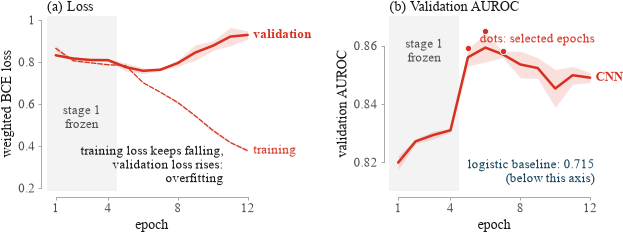

In [31]:
def history_frame(weighted):
    return pd.concat([pd.DataFrame(cnn[(s, weighted)]["history"]).assign(seed=s) for s in TRAIN_SEEDS])

hist = history_frame(True)
mean_curve = hist.groupby("epoch")[["train_loss", "val_loss", "val_auroc"]].mean()
n1 = CNN_CONFIG["stage1_epochs"]

fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.38))
by_epoch = hist.groupby("epoch")
train_style = {"color": RED, "zorder": 3, "plot": dict(color=RED, lw=0.9, ls="--", zorder=3, label="training")}
val_style = {"color": RED, "zorder": 4, "plot": dict(color=RED, lw=1.8, ls="-", zorder=4, label="validation")}
ax = axes[0]                                                   # (a) loss, mean ± SD over seeds
for col, st in [("train_loss", train_style), ("val_loss", val_style)]:
    m, sd = by_epoch[col].mean(), by_epoch[col].std()
    band(ax, m.index, m, m - sd, m + sd, st)
ax.set_xlabel("epoch")
ax.set_ylabel("weighted BCE loss")
ax.set_title("(a) Loss")
finish(ax)
epoch_axis(ax)
shade_stage1(ax)
label_lines(ax)
last_epoch = mean_curve.index.max()

ax = axes[1]                                                   # (b) validation AUROC, mean ± SD over seeds
m, sd = by_epoch.val_auroc.mean(), by_epoch.val_auroc.std()
band(ax, m.index, m, m - sd, m + sd, {**val_style, "plot": {**val_style["plot"], "label": "CNN"}})

for s_ in TRAIN_SEEDS:                                        # selected epoch of each seed
    h = hist[(hist.seed == s_) & (hist.stage == 2)]
    best = h.val_auroc.idxmax()
    ax.plot(h.epoch[best], h.val_auroc[best], "o", ms=4.5, color=RED, mec="white", mew=0.6, zorder=5, label="_best")
ax.set_xlabel("epoch")
ax.set_ylabel("validation AUROC")
ax.set_title("(b) Validation AUROC")
finish(ax)
epoch_axis(ax)
auroc_axis(ax)
shade_stage1(ax, 0.8)
label_lines(ax)
place_text(ax, "dots: selected epochs", prefer=(0.62, 0.97), color=text_color(RED))
place_text(ax, f"logistic baseline: {np.mean(logistic_val_auroc):.3f}\n(below this axis)", prefer=(0.98, 0.03),
           color=text_color(method_style("logistic")["color"]))
place_text(axes[0], "training loss keeps falling,\nvalidation loss rises:\noverfitting", prefer=(0.98, 0.03))
fig.get_layout_engine().set(wspace=0.08)
save_and_show(fig, "E4_learning_curves")

**Figure E4.** Fine-tuning raises validation AUROC from 0.83 to about 0.86 within one to three epochs. After that the training loss keeps falling while the validation loss rises, which is overfitting. Lines are means over three seeds with ±1 SD bands; dots mark the epoch kept for each seed.

In [32]:
last = mean_curve.iloc[-1]
# history rows are numbered from 0, epochs from 1, hence the + 1
best_epochs = [int(pd.DataFrame(cnn[(s, True)]["history"]).query("stage == 2").val_auroc.idxmax()) + 1 for s in TRAIN_SEEDS]
print(f"final epoch (mean over seeds): train loss {last.train_loss:.4f}, val loss {last.val_loss:.4f}, "
      f"val AUROC {last.val_auroc:.4f}; lowest mean val loss at epoch {mean_curve.val_loss.idxmin()}; "
      f"selected epochs per seed: {best_epochs}")

final epoch (mean over seeds): train loss 0.3776, val loss 0.9283, val AUROC 0.8490; lowest mean val loss at epoch 6; selected epochs per seed: [7, 5, 6]


**Under- or overfitting?**
* **Stage 1 underfits.** Training and validation loss stay close and level off, and validation AUROC only rises from 0.8173 to 0.8316 (seed 0). A single linear layer on fixed features seems to lack capacity.
* **Stage 2 overfits after a few epochs.** Validation AUROC jumps to about 0.86 in the first one to three epochs. Then the training loss keeps falling (0.3776 at epoch 12) while the validation loss rises (0.9283), so `layer4` starts to memorise the training images.

Keeping the epoch with the best validation AUROC (epochs 7, 5 and 6) works as early stopping. A lower learning rate would also help: 3e-5 reached almost the same AUROC (0.8577 vs 0.8583) without the rising validation loss.

### E.6 Seeds and validation results
| seed | used for |
|---|---|
| `SPLIT_SEED = 2440` | the patient split, the example images and the augmentation demo |
| `TRAIN_SEEDS = [0, 1, 2]` | head initialisation, batch order and augmentation in each run; logistic initialisation |
| `2440` | bootstrap resampling and the X1 test subsets |
| `1000`–`1499` | the 500 repeated X1 subsets |

Retraining all runs from a clean copy gave exactly the same results, so the spread below comes from the seeds only.

In [33]:
seed_table = pd.DataFrame([{
    "seed": s,
    "stage-1 val AUROC": max(h["val_auroc"] for h in cnn[(s, True)]["history"] if h["stage"] == 1),
    "stage-2 val AUROC": max(h["val_auroc"] for h in cnn[(s, True)]["history"] if h["stage"] == 2),
    "logistic val AUROC": roc_auc_score(y_val, logistic_val_p[s]),
} for s in TRAIN_SEEDS]).set_index("seed")
seed_table.loc["mean"] = seed_table.mean()
seed_table.loc["SD"] = seed_table.iloc[:len(TRAIN_SEEDS)].std(ddof=1)   # sample SD over the seed rows only
display(style_table(seed_table, precision=4, caption="Validation AUROC per seed (test-set results in Section F)"))

,stage-1 val AUROC,stage-2 val AUROC,logistic val AUROC
seed,,,
0,0.8316,0.8583,0.7145
1,0.8310,0.8593,0.7145
2,0.8303,0.8650,0.7145
mean,0.8310,0.8608,0.7145
SD,0.0006,0.0036,0.0000


### E.7 Effect of the weighted loss
We train the same model again with the three seeds but without `pos_weight` (plain BCE), and compare both on the validation set at the default threshold of 0.5.

In [34]:
for seed in TRAIN_SEEDS:
    frozen_model, finetuned_model, history = train_cnn(seed, weighted_loss=False)
    cnn[(seed, False)] = {"frozen": frozen_model, "finetuned": finetuned_model, "history": history}

val_p = {key: predict(v["finetuned"], val_ds) for key, v in cnn.items()}      # validation probabilities

rows = []
for weighted in (True, False):
    for s in TRAIN_SEEDS:
        p = val_p[(s, weighted)]
        rows.append({"loss": "weighted BCE" if weighted else "plain BCE", "seed": s, **ranking_metrics(y_val, p),
                     **metrics_at_threshold(y_val, p, 0.5), "mean predicted p": p.mean()})
imbalance = pd.DataFrame(rows)
cols = ["AUROC", "AUPRC", "sensitivity", "specificity", "precision", "F1", "accuracy", "mean predicted p"]
imbalance_summary = imbalance.groupby("loss")[cols].agg(["mean", "std"])   # mean and SD over the 3 seeds
imbalance_display = pd.DataFrame({c: imbalance_summary[c]["mean"].map("{:.3f}".format) + " ± "
                                     + imbalance_summary[c]["std"].map("{:.3f}".format) for c in cols})
display(style_table(imbalance_display, caption=f"Validation metrics at threshold 0.5, mean ± SD over seeds "
                                               f"(validation prevalence {y_val.mean():.3f})"))

[resnet18_unweighted_lr0.0001_seed0] training on mps


  stage 1 epoch  1 | train loss 0.4309 | val loss 0.4183 | val AUROC 0.8187 | 34s


  stage 1 epoch  2 | train loss 0.4023 | val loss 0.4228 | val AUROC 0.8266 | 34s


  stage 1 epoch  3 | train loss 0.3978 | val loss 0.4075 | val AUROC 0.8289 | 35s


  stage 1 epoch  4 | train loss 0.3949 | val loss 0.4133 | val AUROC 0.8311 | 34s


...

  stage 2 epoch  9 | train loss 0.2766 | val loss 0.4061 | val AUROC 0.8493 | 45s


  stage 2 epoch 10 | train loss 0.2375 | val loss 0.4399 | val AUROC 0.8471 | 40s


  stage 2 epoch 11 | train loss 0.2091 | val loss 0.4596 | val AUROC 0.8512 | 39s


  stage 2 epoch 12 | train loss 0.1853 | val loss 0.4583 | val AUROC 0.8489 | 39s
[resnet18_unweighted_lr0.0001_seed2] best val AUROC: stage 1 0.8293 (epoch 4), stage 2 0.8652 (epoch 6)


,AUROC,AUPRC,sensitivity,specificity,precision,F1,accuracy,mean predicted p
loss,,,,,,,,
plain BCE,0.861 ± 0.003,0.657 ± 0.005,0.562 ± 0.094,0.910 ± 0.030,0.655 ± 0.041,0.600 ± 0.039,0.831 ± 0.002,0.245 ± 0.044
weighted BCE,0.861 ± 0.004,0.652 ± 0.004,0.822 ± 0.040,0.742 ± 0.034,0.486 ± 0.021,0.610 ± 0.007,0.760 ± 0.017,0.408 ± 0.029


PASS C4_imbalance_effect: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/C4_imbalance_effect.png


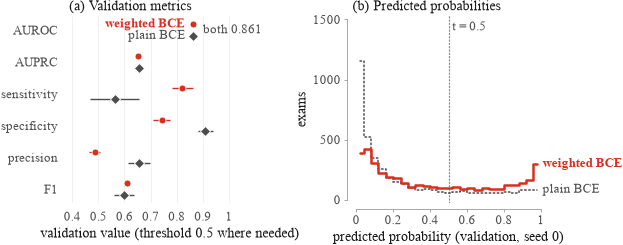

In [35]:
fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.40), width_ratios=[1.05, 1])
sw, sp = method_style("cnn"), method_style("cnn_plain")

ax = axes[0]                                                   # (a) dot plot: mean ± SD over seeds
metric_names = ["AUROC", "AUPRC", "sensitivity", "specificity", "precision", "F1"]
ypos = np.arange(len(metric_names))[::-1]
for loss, s, dy in [("weighted BCE", sw, 0.18), ("plain BCE", sp, -0.18)]:
    means = np.array([imbalance_summary.loc[loss, (m, "mean")] for m in metric_names])
    sds = np.array([imbalance_summary.loc[loss, (m, "std")] for m in metric_names])
    for m_, sd_, y_ in zip(means, sds, ypos + dy):            # one call per dot: nothing connects the rows
        ax.errorbar(m_, y_, xerr=sd_, fmt=s["marker"], ms=5, color=s["color"], mec="white", mew=0.6,
                    elinewidth=1.0, zorder=s["zorder"])
def mean_sd(loss, metric):
    return imbalance_summary.loc[loss, (metric, "mean")], imbalance_summary.loc[loss, (metric, "std")]

for loss, s, dy, bold in [("weighted BCE", sw, 0.18, "bold"), ("plain BCE", sp, -0.18, "normal")]:
    m_, s_ = mean_sd(loss, "AUROC")                          # direct labels beside the top row act as the legend
    ax.text(m_ - s_ - 0.025, ypos[0] + dy, loss, va="center", ha="right", fontsize=TICK_PT, fontweight=bold,
            color=text_color(s["color"]))
auc_w, _ = mean_sd("weighted BCE", "AUROC")
ax.text(auc_w + 0.04, ypos[0], f"both {auc_w:.3f}", va="center", fontsize=TICK_PT, color=MUTED)
ax.set_yticks(ypos, metric_names)
ax.set_xlabel("validation value (threshold 0.5 where needed)")
ax.set_title("(a) Validation metrics")
finish(ax, categorical="y", grid="x")
ax.set_xlim(right=1.16)

ax = axes[1]                                                   # (b) predicted-probability distributions
bins = np.linspace(0, 1, 26)
for weighted, s in [(False, sp), (True, sw)]:
    counts_, edges = np.histogram(val_p[(TRAIN_SEEDS[0], weighted)], bins=bins)
    ax.plot(edges[:-1] + 0.02, counts_, color=s["color"], lw=s["lw"], ls=s["linestyle"], drawstyle="steps-mid",
            zorder=s["zorder"], label="weighted BCE" if weighted else "plain BCE")
ax.axvline(0.5, color=NEUTRALS[1], lw=0.9, ls=":")
ax.set_xlabel("predicted probability (validation, seed 0)")
ax.set_ylabel("exams")
ax.set_title("(b) Predicted probabilities")
finish(ax)
ax.text(0.52, ax.get_ylim()[1] * 0.97, "t = 0.5", ha="left", va="top", fontsize=TICK_PT, color=MUTED)
label_lines(ax)
fig.get_layout_engine().set(wspace=0.08)
save_and_show(fig, "C4_imbalance_effect")

**Figure C4.** The weighted loss raises sensitivity at t = 0.5 from 0.562 to 0.822 but leaves AUROC unchanged (0.861 for both). (a) Validation metrics, mean ± SD over three seeds. (b) Predicted probabilities for seed 0.

**Effect of the weighted loss.** At t = 0.5, weighting raises sensitivity from 0.562 to 0.822 but lowers specificity from 0.910 to 0.742 and precision from 0.655 to 0.486. F1 barely changes (0.600 vs 0.610) and AUROC does not change at all (0.861 for both). So the weight does not make the model better at ranking; it only shifts the predicted probabilities upwards (panel b), as if positives were 3.555 times more common. A plain model with a lower threshold would do the same, and once each model gets its own threshold from validation (Section F) the two perform the same on test. The cost of weighting is calibration (F.6). We keep it because the brief asks for an imbalance strategy and it gives high sensitivity at the default threshold.

---
## F. Evaluation

### F.0 Choose the thresholds on the validation set
We pick two thresholds for every model and seed, using only validation data:
* **Screening:** the highest threshold that still catches at least 90% of positives (sensitivity ≥ 0.90). Missing an opacity is the worse error when screening.
* **High specificity:** the lowest threshold that keeps at least 95% of negatives correct (specificity ≥ 0.95), for when a positive call should be reliable.

The thresholds are then fixed and applied to the test set.

In [36]:
def screening_threshold(y, p, min_sensitivity=0.90):
    """Highest threshold with sensitivity >= min_sensitivity (maximises specificity under that constraint)."""
    fpr, tpr, thr = roc_curve(y, p, drop_intermediate=False)       # every threshold, sorted from high to low
    # argmax of a True/False array gives the first True: the highest threshold with enough sensitivity
    return float(thr[np.argmax(tpr >= min_sensitivity)])

def high_specificity_threshold(y, p, min_specificity=0.95):
    """Lowest threshold with specificity >= min_specificity (maximises sensitivity under that constraint)."""
    fpr, tpr, thr = roc_curve(y, p, drop_intermediate=False)
    # specificity = 1 - fpr; the last True is the lowest threshold that meets the target
    return float(thr[np.flatnonzero(1 - fpr >= min_specificity)[-1]])

# Model names come from figures/methods.json, the single source of truth for labels, colours and line styles.
LABEL = {key: method_style(key)["label"] for key in ["trivial", "logistic", "cnn_frozen", "cnn", "cnn_plain"]}
HEADLINE = LABEL["cnn"]                                                   # the headline model
MODEL_NAMES = [LABEL[k] for k in ["logistic", "cnn_frozen", "cnn", "cnn_plain"]]

# validation probabilities for every model and seed
VAL_P = {(LABEL["logistic"], s): logistic_val_p[s] for s in TRAIN_SEEDS}
for s in TRAIN_SEEDS:
    VAL_P[(LABEL["cnn_frozen"], s)] = predict(cnn[(s, True)]["frozen"], val_ds)
    VAL_P[(HEADLINE, s)] = val_p[(s, True)]
    VAL_P[(LABEL["cnn_plain"], s)] = val_p[(s, False)]

THRESHOLDS = {key: {"screening": screening_threshold(y_val, p), "high_spec": high_specificity_threshold(y_val, p)}
              for key, p in VAL_P.items()}

# representative model for single-model figures: the headline seed with the best *validation* AUROC
REP_SEED = max(TRAIN_SEEDS, key=lambda s: roc_auc_score(y_val, VAL_P[(HEADLINE, s)]))
rep_thr = THRESHOLDS[(HEADLINE, REP_SEED)]
print(f"representative headline model: seed {REP_SEED} (best validation AUROC)")
print(f"frozen thresholds for it: screening t = {rep_thr['screening']:.4f}, high-specificity t = {rep_thr['high_spec']:.4f}")

representative headline model: seed 2 (best validation AUROC)
frozen thresholds for it: screening t = 0.3963, high-specificity t = 0.8970


### F.1 Open the test set
This is the first cell that uses the test images. As a simple check, it looks through the code of all earlier cells (`In`) and confirms that only the cell that defined `test_rows` mentioned it. The check assumes the notebook was run from the top.

In [37]:
# `In` is IPython's list of the source code of every cell executed so far; [:-1] leaves out this execution.
# A set counts a re-run cell once, and earlier runs of this cell itself are left out.
earlier_cells = {src for src in In[:-1] if "test_rows" in src and "TEST_SET_OPENED = True" not in src}
assert len(earlier_cells) == 1, "the test split was used before Section F (restart the kernel and run all)"
TEST_SET_OPENED = True

y_test = exams.y.to_numpy()[test_rows]
test_ds = CXRDataset(IMAGES[test_rows], y_test, augment=False)
X_test_feat = standardise(image_summary_features(IMAGES[test_rows]))

TEST_P = {(LABEL["trivial"], 0): np.full(len(y_test), float(MAJORITY_CLASS))}
for s in TRAIN_SEEDS:
    TEST_P[(LABEL["logistic"], s)] = predict_logistic(logistic_models[s], X_test_feat)
    TEST_P[(LABEL["cnn_frozen"], s)] = predict(cnn[(s, True)]["frozen"], test_ds)
    TEST_P[(HEADLINE, s)] = predict(cnn[(s, True)]["finetuned"], test_ds)
    TEST_P[(LABEL["cnn_plain"], s)] = predict(cnn[(s, False)]["finetuned"], test_ds)
print(f"test set: {len(y_test):,} exams, prevalence {y_test.mean():.3f}; predictions for {len(TEST_P)} model/seed pairs")

test set: 3,777 exams, prevalence 0.216; predictions for 13 model/seed pairs


### F.2 Confusion matrices of the main CNN

PASS F1_confusion_matrices: 0 errors, 0 warnings, 6 taste notes -> figures/_preview/F1_confusion_matrices.png
  [taste] contrast: '1,903' is too light to read; use text_color()
  [taste] contrast: '64.2%' is too light to read; use text_color()
  [taste] contrast: '727' is too light to read; use text_color()
  [taste] contrast: ... 3 more (see _audit/F1_confusion_matrices.json)


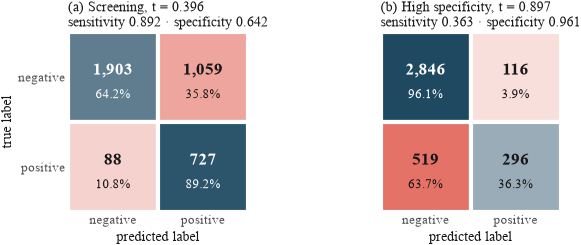

In [38]:
rep_test_p = TEST_P[(HEADLINE, REP_SEED)]
rep_val_p = VAL_P[(HEADLINE, REP_SEED)]
operating_points = {"Screening": rep_thr["screening"], "High specificity": rep_thr["high_spec"]}

op_rows = {}
for name, t in operating_points.items():
    op_rows[(name, "validation")] = metrics_at_threshold(y_val, rep_val_p, t)
    op_rows[(name, "test")] = metrics_at_threshold(y_test, rep_test_p, t)
op_table = pd.DataFrame(op_rows).T[["threshold", "TP", "FP", "TN", "FN", "accuracy", "sensitivity",
                                    "specificity", "precision", "F1"]]
display(style_table(op_table.astype(float), precision=3,
                    caption=f"Headline CNN (seed {REP_SEED}) at the two frozen thresholds"))

fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.40), sharey=True)
for ax, letter, (name, t) in zip(axes, "ab", operating_points.items()):
    m = op_rows[(name, "test")]
    cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    row_share = cm / cm.sum(1, keepdims=True)
    for i in range(2):
        for j in range(2):
            base = NEG if i == j else POS                                # correct calls petrol, errors red
            face = tint(base, 0.12 + 0.88 * row_share[i, j])             # darker = larger share of the true-label row
            ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=face, edgecolor="white", linewidth=3))
            ax.text(j + 0.5, i + 0.43, f"{cm[i, j]:,}", ha="center", va="center", fontsize=LABEL_PT + 2, fontweight="bold",
                    color=readable_on(face))
            ax.text(j + 0.5, i + 0.7, f"{row_share[i, j]:.1%}", ha="center", va="center", fontsize=TICK_PT, color=readable_on(face))
    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5], ["negative", "positive"])
    ax.set_yticks([0.5, 1.5], ["negative", "positive"])
    ax.set_xlabel("predicted label")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_aspect("equal")
    ax.set_title(f"({letter}) {name}, t = {t:.3f}\nsensitivity {m['sensitivity']:.3f} · specificity {m['specificity']:.3f}")
axes[0].set_ylabel("true label")
save_and_show(fig, "F1_confusion_matrices")

**Figure F1.** At the screening threshold the CNN finds 727 of 815 positive test exams but raises 1,059 false alarms. The high-specificity threshold does the opposite (116 false alarms, 519 missed). Seed 2; the shade shows the share of the true-label row.

### F.3 Comparison table
All models use the same test split, metrics and threshold rules. Models trained with seeds are shown as mean ± SD over the three seeds. The trivial model never predicts positive, so its precision is undefined.

In [39]:
def evaluate(model_name, seed):
    y, p = y_test, TEST_P[(model_name, seed)]
    out = {"model": model_name, "seed": seed, **ranking_metrics(y, p)}
    thr = THRESHOLDS.get((model_name, seed), {"screening": 0.5, "high_spec": 0.5})   # trivial: any t gives all-negative
    for op, t in thr.items():
        for k, v in metrics_at_threshold(y, p, t).items():
            if k in ("accuracy", "sensitivity", "specificity", "precision", "F1"):
                out[f"{op}: {k}"] = v
    return out

results = pd.DataFrame([evaluate(name, s) for (name, s) in TEST_P])
metric_cols = [c for c in results.columns if c not in ("model", "seed")]
order = [LABEL["trivial"]] + MODEL_NAMES
agg = results.groupby("model")[metric_cols].agg(["mean", "std"]).reindex(order)

def fmt(mean, sd):
    if np.isnan(mean):
        return "–"
    return f"{mean:.3f}" if np.isnan(sd) else f"{mean:.3f} ± {sd:.3f}"

comparison = pd.DataFrame({c: [fmt(agg.loc[mn, (c, "mean")], agg.loc[mn, (c, "std")]) for mn in order] for c in metric_cols},
                          index=order)
comparison.columns = pd.MultiIndex.from_tuples(
    [("threshold-free", c) if ":" not in c else (("screening (sens ≥ 0.90 on val)" if c.startswith("screening")
                                                   else "high specificity (spec ≥ 0.95 on val)"), c.split(": ")[1])
     for c in comparison.columns])
display(style_table(comparison, caption=f"Test-set comparison (n = {len(y_test):,}, prevalence {y_test.mean():.3f}); "
                                        "mean ± SD over seeds 0, 1, 2"))

### F.4 Is the CNN really better?
We look at two kinds of noise: training noise (how much the test AUROC changes between seeds) and test-sample noise (a paired bootstrap that resamples the test exams 2,000 times and scores both models on the same resample).

In [40]:
auroc_by_seed = results.pivot(index="seed", columns="model", values="AUROC")
cnn_auc, log_auc = auroc_by_seed[HEADLINE].dropna(), auroc_by_seed[LABEL["logistic"]].dropna()
gap = cnn_auc.mean() - log_auc.mean()
print("Primary metric: test AUROC")
print(f"  CNN (headline)    : {', '.join(f'{v:.4f}' for v in cnn_auc)}  ->  mean {cnn_auc.mean():.4f} ± SD {cnn_auc.std(ddof=1):.4f}")
print(f"  logistic baseline : {', '.join(f'{v:.4f}' for v in log_auc)}  ->  mean {log_auc.mean():.4f} ± SD {log_auc.std(ddof=1):.4f}")
print(f"  gap = {gap:.4f}, which is {gap / max(cnn_auc.std(ddof=1), 1e-12):.0f}× the CNN's seed-to-seed SD; "
      f"smallest CNN seed {cnn_auc.min():.4f} vs largest logistic seed {log_auc.max():.4f}")

rng_boot = np.random.default_rng(2440)
boot_diff = []
p_cnn, p_log = TEST_P[(HEADLINE, REP_SEED)], TEST_P[(LABEL["logistic"], REP_SEED)]
for _ in range(2000):
    idx = rng_boot.integers(0, len(y_test), len(y_test))         # draw n test exams with replacement
    # both models are scored on the SAME resample, so the difference is paired
    boot_diff.append(roc_auc_score(y_test[idx], p_cnn[idx]) - roc_auc_score(y_test[idx], p_log[idx]))
ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])            # middle 95% of the 2,000 differences
print(f"  paired bootstrap (seed {REP_SEED}): AUROC difference {np.mean(boot_diff):.4f}, 95% CI [{ci_low:.4f}, {ci_high:.4f}]")

# frozen features vs fine-tuning: is the stage-2 gain larger than seed noise?
frz = auroc_by_seed[LABEL["cnn_frozen"]].dropna()
print(f"  frozen-feature CNN: mean {frz.mean():.4f} ± {frz.std(ddof=1):.4f}; fine-tuning adds {cnn_auc.mean() - frz.mean():.4f}")

Primary metric: test AUROC
  CNN (headline)    : 0.8537, 0.8570, 0.8615  ->  mean 0.8574 ± SD 0.0040
  logistic baseline : 0.6889, 0.6889, 0.6889  ->  mean 0.6889 ± SD 0.0000
  gap = 0.1685, which is 43× the CNN's seed-to-seed SD; smallest CNN seed 0.8537 vs largest logistic seed 0.6889


  paired bootstrap (seed 2): AUROC difference 0.1729, 95% CI [0.1545, 0.1914]
  frozen-feature CNN: mean 0.8310 ± 0.0013; fine-tuning adds 0.0264


**Seeds and run-to-run variation.** Our main metric is test AUROC, because it depends on neither the threshold nor the prevalence.
* CNN, seeds 0, 1 and 2: 0.8537, 0.8570 and 0.8615, so **0.857 ± 0.004**.
* Logistic baseline: **0.689** for every seed, because the problem is convex and all seeds reach the same solution.
* The gap (0.1685) is about 43 times the CNN's seed SD, and the bootstrap gives a difference of 0.1729 with a 95% CI of [0.1545, 0.1914]. The improvement is far larger than both kinds of noise.
* Fine-tuning adds 0.0264 over frozen features, about six seed SDs, so it is probably real but small. Weighted and plain BCE give the same AUROC.

Three seeds only give a rough SD, and we used one fixed patient split. From here on, single-model results use seed 2 because it had the best validation AUROC. It also has the best test AUROC (0.8615), so its numbers are slightly above the mean.

**A controlled comparison.** The CNN and the logistic baseline use the same split, the same cached images, the same weighted loss, the same seeds, the same validation-based choices and threshold rules, and the same metric code on the same test set. They differ only in the model and how it is trained (15 summary features and full-batch Adam versus the pixels and mini-batch AdamW with augmentation). So the difference in the table comes from the modelling approach, not from how the data were handled or evaluated.

### F.5 ROC and precision–recall curves

PASS F3_roc_pr_curves: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/F3_roc_pr_curves.png


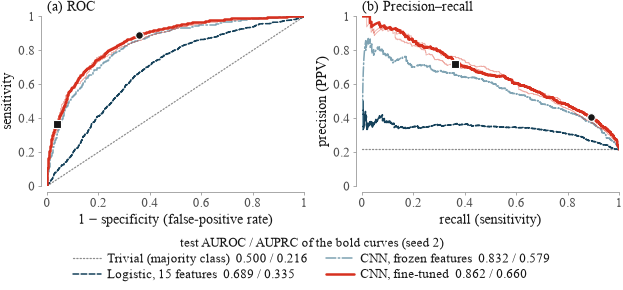

In [41]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=figsize("full", aspect=0.47))
prevalence = y_test.mean()
seed_row = results.set_index(["model", "seed"])

def pr_points(p):
    """Precision-recall points without the degenerate recall = 0 end point (precision is undefined there)."""
    prec, rec, _ = precision_recall_curve(y_test, p)
    keep = rec > 0
    return rec[keep], prec[keep]

handles = []
for key in ["trivial", "logistic", "cnn_frozen", "cnn"]:                     # focus series drawn last
    s = method_style(key)
    if key == "trivial":
        ax_roc.plot([0, 1], [0, 1], **s["plot"])
        ax_pr.plot([0, 1], [prevalence] * 2, **s["plot"])
        text = f"{s['label']}  0.500 / {prevalence:.3f}"
    else:
        p = TEST_P[(s["label"], REP_SEED)]
        fpr, tpr, _ = roc_curve(y_test, p)
        ax_roc.plot(fpr, tpr, **s["plot"])
        ax_pr.plot(*pr_points(p), **s["plot"])
        r_ = seed_row.loc[(s["label"], REP_SEED)]
        text = f"{s['label']}  {r_.AUROC:.3f} / {r_.AUPRC:.3f}"
    handles.append(plt.Line2D([], [], **{**s["plot"], "label": text}))
for seed in TRAIN_SEEDS:                                                    # the other CNN seeds, faint
    if seed != REP_SEED:
        fpr, tpr, _ = roc_curve(y_test, TEST_P[(HEADLINE, seed)])
        ax_roc.plot(fpr, tpr, color=RED, lw=0.6, alpha=0.4, zorder=3, label="_seed")
        ax_pr.plot(*pr_points(TEST_P[(HEADLINE, seed)]), color=RED, lw=0.6, alpha=0.4, zorder=3, label="_seed")
for (name, t), marker in zip(operating_points.items(), ["o", "s"]):        # the two frozen operating points
    m = metrics_at_threshold(y_test, rep_test_p, t)
    ax_roc.plot(1 - m["specificity"], m["sensitivity"], marker, ms=5.5, color=INK, mec="white", mew=0.8, zorder=6, label="_op")
    ax_pr.plot(m["sensitivity"], m["precision"], marker, ms=5.5, color=INK, mec="white", mew=0.8, zorder=6, label="_op")

ax_roc.set_xlabel("1 − specificity (false-positive rate)")
ax_roc.set_ylabel("sensitivity")
ax_roc.set_title("(a) ROC")
ax_pr.set_xlabel("recall (sensitivity)")
ax_pr.set_ylabel("precision (PPV)")
ax_pr.set_title("(b) Precision–recall")
for ax in (ax_roc, ax_pr):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    finish(ax, snap=False)
fig.legend(handles=handles, loc="outside lower center", ncol=2, handlelength=2.2, columnspacing=1.5,
           title=f"test AUROC / AUPRC of the bold curves (seed {REP_SEED})", title_fontsize=TICK_PT)
save_and_show(fig, "F3_roc_pr_curves")

**Figure F3.** The fine-tuned CNN is above the logistic baseline everywhere (test AUROC 0.857 vs 0.689 and AUPRC 0.655 vs 0.335, means over three seeds). Bold lines are seed 2 and thin red lines the other seeds; the circle and square mark the two thresholds; dotted is the trivial model.

**Which curve is more informative here?** Both ROC axes are computed within one class (sensitivity on positives, false-positive rate on negatives), so ROC ignores how rare the positives are. With 78% negatives, a small false-positive rate can still mean many false alarms. Precision answers the clinical question directly: of the exams we flag, how many really have an opacity? Its chance level is the prevalence (0.216), so AUPRC shows how far each model is above chance: 0.655 for the CNN, 0.335 for the logistic model and 0.216 for the trivial model. For example, the screening threshold looks good on the ROC curve (sensitivity 0.892, specificity 0.642), but its precision is only 0.407: 1,059 false alarms for 727 true positives. For this class balance the PR curve is therefore more informative.

**The two thresholds** (seed 2, chosen on validation, then fixed):
* **Screening:** *t* = 0.396. On the test set it finds 727 of 815 positives (sensitivity 0.892) with specificity 0.642 and precision 0.407. It suits triage, where flagged exams are read first.
* **High specificity:** *t* = 0.897. Specificity 0.961 and precision 0.718, but sensitivity only 0.363, so it should never be used to rule out pneumonia.

Test sensitivity (0.892) is slightly below the 0.90 target because the threshold was fitted on the 910 validation positives. Changing it on the test set would be leakage, so we just report it. Note that 0.396 is not a 40% risk: the weighted model's probabilities are inflated (F.6).

In [42]:
thr_table = pd.DataFrame([{
    "operating point": name, "rule (validation)": rule, "frozen threshold": t,
    "val sensitivity": metrics_at_threshold(y_val, rep_val_p, t)["sensitivity"],
    "val specificity": metrics_at_threshold(y_val, rep_val_p, t)["specificity"],
    "test sensitivity": metrics_at_threshold(y_test, rep_test_p, t)["sensitivity"],
    "test specificity": metrics_at_threshold(y_test, rep_test_p, t)["specificity"],
    "test precision": metrics_at_threshold(y_test, rep_test_p, t)["precision"],
} for (name, t), rule in zip(operating_points.items(), ["highest t with sensitivity ≥ 0.90", "lowest t with specificity ≥ 0.95"])]
).set_index("operating point")
display(style_table(thr_table, precision=3, caption=f"Frozen thresholds of the headline CNN (seed {REP_SEED})"))

,rule (validation),frozen threshold,val sensitivity,val specificity,test sensitivity,test specificity,test precision
operating point,,,,,,,
Screening,highest t with sensitivity ≥ 0.90,0.396,0.900,0.629,0.892,0.642,0.407
High specificity,lowest t with specificity ≥ 0.95,0.897,0.409,0.950,0.363,0.961,0.718


### F.6 Calibration
A model is calibrated if, among exams given *p* ≈ 0.3, about 30% really are positive. We group the test predictions into 10 bins and compare the average prediction with the observed positive rate in each bin. We also report the expected calibration error (ECE) and the Brier score (mean squared error of the probabilities). Finally we recalibrate the main CNN with Platt scaling, a small logistic regression *p′ = σ(a · logit(p) + b)* fitted on the validation predictions. It cannot change the order of the predictions, so AUROC stays the same.

Platt scaling fitted on validation: a = 0.816, b = -1.515


PASS F5_reliability: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/F5_reliability.png


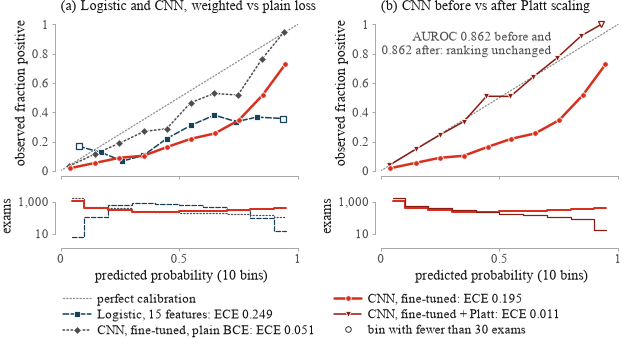

In [43]:
def reliability(y, p, n_bins=10):
    """Per-bin mean prediction, observed positive rate and count, plus ECE and Brier score."""
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)        # bin 0 = [0, 0.1), ..., p = 1.0 joins the last bin
    table = pd.DataFrame({"y": y, "p": p, "bin": bins}).groupby("bin").agg(
        mean_p=("p", "mean"), observed=("y", "mean"), n=("y", "size"))
    # ECE: gap between mean prediction and observed rate, averaged over bins by size
    ece = float((table.n * (table.mean_p - table.observed).abs()).sum() / len(y))
    brier = float(np.mean((p - y) ** 2))                           # mean squared error of the probabilities
    return table, ece, brier

def logit(p, eps=1e-6):
    """Inverse of the sigmoid: probability -> log-odds (clipped so that p = 0 or 1 stays finite)."""
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

from sklearn.linear_model import LogisticRegression
# One input feature (the logit of p) -> learns p' = sigmoid(a * logit(p) + b). C is sklearn's INVERSE penalty
# strength, so C = 1e6 means practically no regularisation; [:, None] makes the (n, 1) matrix sklearn expects.
platt = LogisticRegression(C=1e6).fit(logit(rep_val_p)[:, None], y_val)          # fitted on VALIDATION only
calibrated_test_p = platt.predict_proba(logit(rep_test_p)[:, None])[:, 1]
print(f"Platt scaling fitted on validation: a = {platt.coef_[0, 0]:.3f}, b = {platt.intercept_[0]:.3f}")

calib_models = {                                   # key in figures/methods.json -> test probabilities (seed REP_SEED)
    "cnn": TEST_P[(HEADLINE, REP_SEED)],
    "cnn_plain": TEST_P[(LABEL["cnn_plain"], REP_SEED)],
    "logistic": TEST_P[(LABEL["logistic"], REP_SEED)],
    "cnn_platt": calibrated_test_p,
}
calib_rows = {}
for key, p in calib_models.items():
    table, ece, brier = reliability(y_test, p)
    calib_rows[method_style(key)["label"]] = {"AUROC": roc_auc_score(y_test, p), "ECE": ece, "Brier": brier,
                                             "mean p": p.mean(), "_table": table}

fig, axes = plt.subplots(2, 2, figsize=figsize("full", aspect=0.56), height_ratios=[3, 1], sharex="col")
panels = {0: (["logistic", "cnn_plain", "cnn"], "(a) Logistic and CNN, weighted vs plain loss"),
          1: (["cnn", "cnn_platt"], "(b) CNN before vs after Platt scaling")}
legend_handles = {}
for col, (keys, title) in panels.items():
    ax, ax_n = axes[0, col], axes[1, col]
    ref = method_style("trivial")
    legend_handles["ref"] = ax.plot([0, 1], [0, 1], **{**ref["plot"], "label": "perfect calibration"})[0]
    for key in keys:
        s = method_style(key)
        row = calib_rows[s["label"]]
        t = row["_table"]
        ax.plot(t.mean_p, t.observed, **{**s["plot"], "label": "_curve"})
        dense = t.n >= 30                                                  # bins with < 30 exams: hollow markers
        ax.plot(t.mean_p[dense], t.observed[dense], ls="", marker=s["marker"], ms=4, color=s["color"], mec="white",
                mew=0.6, zorder=s["zorder"] + 1, label="_dense")
        ax.plot(t.mean_p[~dense], t.observed[~dense], ls="", marker=s["marker"], ms=4, mfc="white", mec=s["color"],
                mew=0.9, zorder=s["zorder"] + 1, label="_sparse")
        legend_handles[key] = plt.Line2D([], [], **{**s["plot"], "label": f"{s['label']}: ECE {row['ECE']:.3f}"},
                                         marker=s["marker"], ms=4, mec="white")
        counts_, edges = np.histogram(calib_models[key], bins=np.linspace(0, 1, 11))   # the same 10 bins
        ax_n.plot(edges[:-1] + 0.05, counts_, color=s["color"], lw=s["lw"] * 0.8, ls=s["linestyle"],
                  drawstyle="steps-mid", label="_n")
    ax.set_ylabel("observed fraction positive")
    ax.set_title(title)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.06)                                   # headroom: a bin observed at 1.0 is not clipped
    finish(ax, snap=False)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.spines["left"].set_bounds(0, 1)
    ax_n.set_yscale("log")
    ax_n.set_ylim(3, 5000)
    ax_n.set_yticks([10, 1000], ["10", "1,000"])
    ax_n.yaxis.set_minor_locator(plt.NullLocator())
    ax_n.set_xlabel("predicted probability (10 bins)")
    ax_n.set_ylabel("exams")
    finish(ax_n, snap=False)
fig.get_layout_engine().set(wspace=0.06, hspace=0.06)
legend_handles["hollow"] = plt.Line2D([], [], ls="", marker="o", ms=4, mfc="white", mec=INK, label="bin with fewer than 30 exams")
fig.legend(handles=[legend_handles[k] for k in ["ref", "logistic", "cnn_plain", "cnn", "cnn_platt", "hollow"]],
           loc="outside lower center", ncol=2, handlelength=2.2, columnspacing=1.5)
place_text(axes[0, 1], f"AUROC {calib_rows[HEADLINE]['AUROC']:.3f} before and\n"            # placed last: the legend
                       f"{calib_rows[method_style('cnn_platt')['label']]['AUROC']:.3f} after: ranking unchanged",  # changes the layout
           prefer=(0.98, 0.03), color=MUTED)
save_and_show(fig, "F5_reliability")

**Figure F5.** The weighted CNN over-predicts (ECE 0.195). Platt scaling fitted on validation fixes this (ECE 0.011) without changing AUROC (0.862). Hollow markers are bins with fewer than 30 exams; the strips below show how many exams fall in each bin.

In [44]:
for label, r_ in calib_rows.items():                  # which bins are drawn hollow (fewer than 30 exams)
    sparse = r_["_table"][r_["_table"].n < 30]
    print(f"{label}: sparse bins at p ≈ {', '.join(f'{m:.2f} (n = {n})' for m, n in zip(sparse.mean_p, sparse.n)) or 'none'}")
calib_summary = pd.DataFrame({k: {c: v for c, v in r.items() if c != "_table"} for k, r in calib_rows.items()}).T
display(style_table(calib_summary, precision=3, caption="Calibration summary (test set)"))

platt_label = method_style("cnn_platt")["label"]

CNN, fine-tuned: sparse bins at p ≈ none
CNN, fine-tuned, plain BCE: sparse bins at p ≈ none
Logistic, 15 features: sparse bins at p ≈ 0.08 (n = 6), 0.94 (n = 14)
CNN, fine-tuned + Platt: sparse bins at p ≈ 0.93 (n = 17)


,AUROC,ECE,Brier,mean p
"CNN, fine-tuned",0.862,0.195,0.173,0.411
"CNN, fine-tuned, plain BCE",0.862,0.051,0.118,0.266
"Logistic, 15 features",0.689,0.249,0.223,0.465
"CNN, fine-tuned + Platt",0.862,0.011,0.114,0.211


**Discrimination versus calibration.** Discrimination is how well the model ranks positives above negatives (AUROC). Calibration is whether the probabilities can be taken at face value. They are different things:
* The weighted CNN ranks well (AUROC 0.862) but over-predicts in every bin (ECE 0.195). Its mean prediction is 0.411 while only 0.216 of test exams are positive. This comes from `pos_weight`.
* The plain-BCE CNN has the same AUROC but a much lower ECE (0.051).
* Platt scaling (*a* = 0.816, *b* = −1.515) lowers the ECE to 0.011 and the Brier score from 0.173 to 0.114, while AUROC stays 0.862. It only rescales the probabilities, which shows that calibration can be fixed without touching discrimination.
* The logistic baseline is poor at both (AUROC 0.689, ECE 0.249).

If these probabilities were shown to clinicians, they would first need recalibration on local data.

---
## G. Interpretation and error analysis
This section uses the seed-2 CNN on the test set at the screening threshold.

In [45]:
test_exams = exams.iloc[test_rows].reset_index(drop=True)          # metadata of the test exams, same order as y_test
test_exams["p"] = rep_test_p
test_exams["pred"] = (rep_test_p >= rep_thr["screening"]).astype(int)   # 1 = called positive
# np.select gives each row the label of the (only) condition that is true for it
test_exams["outcome"] = np.select(
    [(test_exams.y == 1) & (test_exams.pred == 1), (test_exams.y == 0) & (test_exams.pred == 0),
     (test_exams.y == 0) & (test_exams.pred == 1), (test_exams.y == 1) & (test_exams.pred == 0)],
    ["TP", "TN", "FP", "FN"], default="")
print(test_exams.outcome.value_counts().reindex(["TP", "TN", "FP", "FN"]).to_dict())

{'TP': 727, 'TN': 1903, 'FP': 1059, 'FN': 88}


### G.1 Correct and incorrect predictions
For each outcome (TP, TN, FP, FN) we show a typical exam, the one at the median probability of its group, and the most extreme one, which is the most confident correct call or mistake.

PASS G1_error_examples: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/G1_error_examples.png


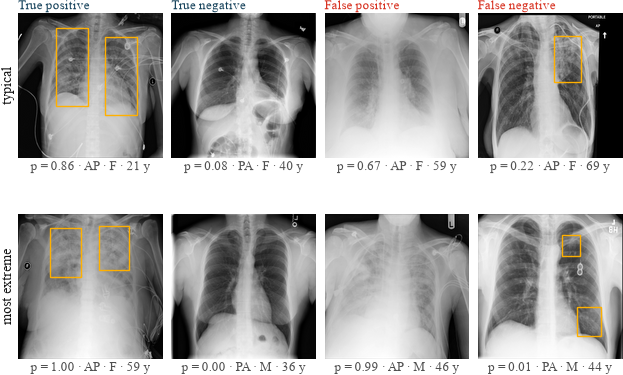

In [46]:
OUTCOMES = {"TP": "True positive", "TN": "True negative", "FP": "False positive", "FN": "False negative"}

def outcome_examples(outcome):
    """Row index of a typical and of the most extreme exam of one outcome group."""
    g = test_exams[test_exams.outcome == outcome]
    typical = (g.p - g.p.median()).abs().idxmin()                        # p closest to the group's median
    # most confident: highest p for TP/FP, lowest p for TN/FN
    extreme = g.p.idxmax() if outcome in ("TP", "FP") else g.p.idxmin()
    return {"typical": typical, "most extreme": extreme}

G1_EXAMPLES = {o: outcome_examples(o) for o in OUTCOMES}

fig, axes = plt.subplots(2, 4, figsize=figsize("full", aspect=0.62))
g1_rows = []
for c, (o, label) in enumerate(OUTCOMES.items()):
    for r, kind in enumerate(["typical", "most extreme"]):
        i = G1_EXAMPLES[o][kind]
        row = test_exams.loc[i]
        show_xray(axes[r, c], IMAGES[test_rows[i]], title=label if r == 0 else None,
                  title_color=POS if o in ("FP", "FN") else NEG,           # errors red, correct calls petrol (as in F1)
                  note=f"p = {row.p:.2f} · {row.view} · {row.sex} · {row.age} y",
                  boxes=BOXES.get(row.patientId), box_scale=IMG_SIZE / 1024)
        g1_rows.append({"outcome": label, "example": kind, "p": row.p, "view": row.view, "sex": row.sex, "age": row.age})
for r, kind in enumerate(["typical", "most extreme"]):
    axes[r, 0].set_ylabel(kind, fontsize=LABEL_PT, color=INK)
fig.get_layout_engine().set(hspace=0.1)
display(style_table(pd.DataFrame(g1_rows).set_index(["outcome", "example"]), precision=3, caption="Examples shown in Figure G1"))
save_and_show(fig, "G1_error_examples")

**Figure G1.** The worst mistakes are made with high confidence: a false positive at p = 0.99 and a missed opacity at p = 0.01. The false positive has hazy lungs on both sides, so its label may be debatable. Gold rectangles are the annotated opacities.

### G.2 Subgroups
The headers give us projection (AP/PA), sex and age. For each group we report its size, number of positives, AUROC with a 95% bootstrap interval, and sensitivity and specificity at the screening threshold. We also check how well the projection alone ranks the exams.

In [47]:
def bootstrap_auroc(y, p, n_boot=1000, seed=2440):
    """95% bootstrap confidence interval of the AUROC: resample the exams with replacement n_boot times."""
    rng_b = np.random.default_rng(seed)
    stats = []
    for _ in range(n_boot):
        idx = rng_b.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(idx):                      # both classes needed for an AUROC
            stats.append(roc_auc_score(y[idx], p[idx]))
    return np.percentile(stats, [2.5, 97.5])

# age bands (0, 39], (39, 59], (59, 200]; the impossible ages above 100 fall into the last band
test_exams["age group"] = pd.cut(test_exams.age, [0, 39, 59, 200], labels=["< 40 y", "40–59 y", "≥ 60 y"])
subgroups = [("All test exams", np.ones(len(test_exams), bool))]
subgroups += [(f"View · {v}", (test_exams.view == v).to_numpy()) for v in ["PA", "AP"]]
subgroups += [(f"Sex · {'female' if s == 'F' else 'male'}", (test_exams.sex == s).to_numpy()) for s in ["F", "M"]]
subgroups += [(f"Age · {a}", (test_exams["age group"] == a).to_numpy()) for a in ["< 40 y", "40–59 y", "≥ 60 y"]]

sub_rows = []
for name, mask in subgroups:
    y_s, p_s = y_test[mask], rep_test_p[mask]
    lo, hi = bootstrap_auroc(y_s, p_s)
    m = metrics_at_threshold(y_s, p_s, rep_thr["screening"])
    sub_rows.append({"subgroup": name, "n": int(mask.sum()), "positives": int(y_s.sum()), "prevalence": y_s.mean(),
                     "AUROC": roc_auc_score(y_s, p_s), "95% CI low": lo, "95% CI high": hi,
                     "sensitivity": m["sensitivity"], "specificity": m["specificity"]})
subgroup_table = pd.DataFrame(sub_rows).set_index("subgroup")
display(style_table(subgroup_table, precision=3, caption="Headline CNN by subgroup (test set, screening threshold)"))

# a "model" that only knows the projection: score 1 for AP, 0 for PA
view_only_auroc = roc_auc_score(y_test, (test_exams.view == "AP").astype(float))
print(f"AUROC of the projection alone (AP = 1, PA = 0): {view_only_auroc:.3f}")

# Direct check: within ONE true class the label is fixed, so if the CNN score still separates AP from PA films,
# the score carries projection information beyond the annotated opacity.
is_ap = (test_exams.view == "AP").to_numpy()
proj_auc = {k: roc_auc_score(is_ap[y_test == k], rep_test_p[y_test == k]) for k in (0, 1)}
print(f"how well the CNN score separates AP from PA films within one class (AUROC): "
      f"negatives {proj_auc[0]:.3f}, positives {proj_auc[1]:.3f}")
print(f"{(test_exams.age > 100).sum()} test exam(s) with a recorded age > 100 are kept in the '≥ 60 y' group")

,n,positives,prevalence,AUROC,95% CI low,95% CI high,sensitivity,specificity
subgroup,,,,,,,,
All test exams,"3,777",815,0.216,0.862,0.848,0.876,0.892,0.642
View · PA,"2,086",200,0.096,0.824,0.795,0.855,0.645,0.816
View · AP,"1,691",615,0.364,0.815,0.795,0.834,0.972,0.338
Sex · female,"1,578",313,0.198,0.874,0.853,0.895,0.872,0.655
Sex · male,"2,199",502,0.228,0.852,0.835,0.871,0.904,0.633
Age · < 40 y,"1,218",289,0.237,0.895,0.875,0.915,0.920,0.659
Age · 40–59 y,"1,626",319,0.196,0.854,0.832,0.875,0.884,0.639
Age · ≥ 60 y,933,207,0.222,0.823,0.793,0.854,0.865,0.628


AUROC of the projection alone (AP = 1, PA = 0): 0.696
how well the CNN score separates AP from PA films within one class (AUROC): negatives 0.826, positives 0.818
1 test exam(s) with a recorded age > 100 are kept in the '≥ 60 y' group


PASS G2_subgroups: 0 errors, 0 warnings, 2 taste notes -> figures/_preview/G2_subgroups.png
  [taste] ticks: 8 major ticks; 3-6 is calmer (finish(ax) sets this)
  [taste] ticks: 8 major ticks; 3-6 is calmer (finish(ax) sets this)


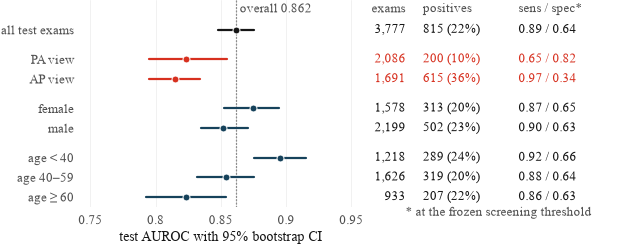

In [48]:
fig, (ax, ax_txt) = plt.subplots(1, 2, figsize=figsize("full", aspect=0.40), width_ratios=[1.25, 1], sharey=True)
row_names = {"All test exams": "all test exams", "View · PA": "PA view", "View · AP": "AP view",
             "Sex · female": "female", "Sex · male": "male", "Age · < 40 y": "age < 40",
             "Age · 40–59 y": "age 40–59", "Age · ≥ 60 y": "age ≥ 60"}
ypos = np.array([9.0, 7.5, 6.5, 5.0, 4.0, 2.5, 1.5, 0.5])        # gaps separate the three groupings
overall = subgroup_table.loc["All test exams", "AUROC"]
ax.axvline(overall, color=NEUTRALS[1], lw=0.9, ls=":", zorder=1)
for y_, (name, r) in zip(ypos, subgroup_table.iterrows()):
    color = INK if name == "All test exams" else RED if name.startswith("View") else PETROL
    ax.plot([r["95% CI low"], r["95% CI high"]], [y_, y_], color=color, lw=1.6, solid_capstyle="round", label="_ci")
    ax.plot(r.AUROC, y_, "o", ms=5, color=color, mec="white", mew=0.7, zorder=5, label="_point")
    txt_color = text_color(RED) if name.startswith("View") else INK
    ax_txt.text(0, y_, f"{int(r.n):,}", va="center", ha="right", fontsize=TICK_PT, color=txt_color,
                transform=ax_txt.get_yaxis_transform())
    ax_txt.text(0.08, y_, f"{int(r.positives):,} ({r.prevalence:.0%})", va="center", fontsize=TICK_PT, color=txt_color,
                transform=ax_txt.get_yaxis_transform())
    ax_txt.text(0.52, y_, f"{r.sensitivity:.2f} / {r.specificity:.2f}", va="center", fontsize=TICK_PT, color=txt_color,
                transform=ax_txt.get_yaxis_transform())
ax.set_yticks(ypos, [row_names[n] for n in subgroup_table.index])
ax.set_xlabel("test AUROC with 95% bootstrap CI")
finish(ax, categorical="y", grid="x")
ax.set_ylim(0, 10.5)
ax.text(overall + 0.003, 9.75, f"overall {overall:.3f}", ha="left", va="bottom", fontsize=TICK_PT, color=MUTED)
for x_, header, ha in [(0, "exams", "right"), (0.08, "positives", "left"), (0.52, "sens / spec*", "left")]:
    ax_txt.text(x_, 9.75, header, ha=ha, va="bottom", fontsize=TICK_PT, color=MUTED, transform=ax_txt.get_yaxis_transform())
ax_txt.text(0, 0, "* at the frozen screening threshold", ha="left", va="top", fontsize=TICK_PT, color=MUTED,
            transform=ax_txt.transAxes)
ax_txt.set_xlim(-0.12, 1)
ax_txt.axis("off")
save_and_show(fig, "G2_subgroups")

**Figure G2.** AUROC within PA images (0.824) and within AP images (0.815) is lower than overall (0.862). Bars are 95% bootstrap intervals; the right side lists group sizes and sensitivity/specificity.

**Interpreting the subgroups.**
* **Projection.** AUROC within PA images (0.824; 2,086 exams, 200 positive) and within AP images (0.815; 1,691 exams, 615 positive) are both lower than the overall 0.862. This is what we would expect if part of the score comes from telling AP from PA apart: AP images are far more often positive (0.364 vs 0.096), and the projection alone already gives an AUROC of 0.696. A direct check agrees: even within one true class, the CNN score separates AP from PA with AUROC 0.826 (negatives) and 0.818 (positives). Part of this could be real, since bedside patients are sicker, so it is evidence of a projection shortcut rather than proof. At the screening threshold, 97% of AP opacities are caught but so are two thirds of AP negatives (specificity 0.338), while a third of PA opacities are missed (sensitivity 0.645). In practice each projection would need its own threshold.
* **Age.** AUROC drops from 0.895 (under 40) to 0.823 (60 and over), and the intervals do not overlap. Age is linked to projection, though, so we cannot separate the two.
* **Sex.** 0.874 for women and 0.852 for men, with overlapping intervals, so there is no clear difference.

These groups are small (only 200 positive PA exams), we compared seven of them, and everything comes from one split and one model. The results show where to look rather than firm conclusions.

### G.3 Grad-CAM
Grad-CAM shows which regions push the opacity score up. For the 512 feature maps *A* (7 × 7) of the chosen layer and the logit *z*:
1. weight each map by its average gradient, $\alpha_k = \frac{1}{49}\sum_{i,j} \partial z / \partial A^k_{ij}$;
2. take $\mathrm{ReLU}\big(\sum_k \alpha_k A^k\big)$ and upsample it to 224 × 224.

**Layer: `model.layer4`.** It is the last layer that still has a spatial layout (the next step averages over space), so it holds the most task-specific features that can still be located, and it is the block we fine-tuned. The downside is resolution: one cell covers 32 × 32 pixels, so a map shows the region of the chest, not the exact structure.

In [49]:
def grad_cam(model, x, layer):
    """Raw Grad-CAM maps (N x 224 x 224, not rescaled) and probabilities for a batch x (N x 1 x 224 x 224)."""
    store = {}

    # A forward hook saves the layer's output A and registers a hook that saves dz/dA during backward().
    def save_activation_and_gradient(module, inputs, output):
        store["A"] = output
        output.register_hook(lambda grad: store.update(dA=grad))   # called during backward()

    handle = layer.register_forward_hook(save_activation_and_gradient)
    model.eval()                                                    # BatchNorm in eval mode: samples are independent
    x = x.to(DEVICE).requires_grad_(True)                           # guarantees a gradient graph even if all weights are frozen
    logits = model(x).squeeze(1)
    model.zero_grad()
    logits.sum().backward()                                         # each sample gets the gradient of its own logit
    handle.remove()                                                 # the hook is only needed for this batch

    alpha = store["dA"].mean(dim=(2, 3), keepdim=True)              # step 1: average gradient per feature map, N x 512 x 1 x 1
    cam = F.relu((alpha * store["A"]).sum(dim=1, keepdim=True))    # step 2: weighted sum of the maps, keep > 0, N x 1 x 7 x 7
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]   # 7 x 7 -> 224 x 224
    return cam.detach().cpu().numpy(), torch.sigmoid(logits).detach().cpu().numpy()

def scale_per_image(cams):
    """Scale each map to [0, 1] for display (this hides differences in overall strength between images)."""
    return cams / (cams.max(axis=(1, 2), keepdims=True) + 1e-8)

def grad_cam_dataset(model, dataset, batch_size=64):
    """Grad-CAM maps and probabilities for every image of `dataset`, in batches."""
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    cams, probs = zip(*(grad_cam(model, x, model.layer4) for x, _ in loader))
    return np.concatenate(cams), np.concatenate(probs)

rep_model = cnn[(REP_SEED, True)]["finetuned"]
TEST_CAMS_RAW, cam_p = grad_cam_dataset(rep_model, test_ds)
TEST_CAMS = scale_per_image(TEST_CAMS_RAW)                             # for display
assert np.allclose(cam_p, rep_test_p, atol=1e-4)                     # same model, same predictions
print(f"Grad-CAM maps for all {len(TEST_CAMS):,} test images: {TEST_CAMS.shape}")

Grad-CAM maps for all 3,777 test images: (3777, 224, 224)


PASS G3_gradcam: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/G3_gradcam.png


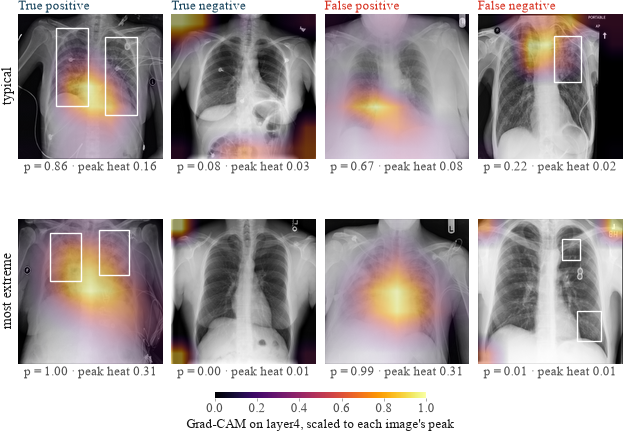

In [50]:
fig, axes = plt.subplots(2, 4, figsize=figsize("full", aspect=0.72))
for c, (o, label) in enumerate(OUTCOMES.items()):
    for r, kind in enumerate(["typical", "most extreme"]):
        i = G1_EXAMPLES[o][kind]
        row = test_exams.loc[i]
        show_xray(axes[r, c], IMAGES[test_rows[i]], title=label if r == 0 else None,
                  title_color=POS if o in ("FP", "FN") else NEG,
                  note=f"p = {row.p:.2f} · peak heat {TEST_CAMS_RAW[i].max():.2f}",
                  boxes=BOXES.get(row.patientId), box_scale=IMG_SIZE / 1024, box_color="white")
        overlay_cam(axes[r, c], TEST_CAMS[i])
for r, kind in enumerate(["typical", "most extreme"]):
    axes[r, 0].set_ylabel(kind, fontsize=LABEL_PT, color=INK)
fig.get_layout_engine().set(hspace=0.07)
display(style_table(pd.DataFrame([{"outcome": OUTCOMES[o], "example": kind, "p": test_exams.p[G1_EXAMPLES[o][kind]],
                                   "peak heat (raw)": TEST_CAMS_RAW[G1_EXAMPLES[o][kind]].max()}
                                  for o in OUTCOMES for kind in ["typical", "most extreme"]]).set_index(["outcome", "example"]),
                    precision=3, caption="Examples shown in Figure G3"))
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1)), ax=axes, location="bottom",
                    shrink=0.35, aspect=35, pad=0.03)
cbar.set_label("Grad-CAM on layer4, scaled to each image's peak", fontsize=TICK_PT, color=INK)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=TICK_PT, length=2)
save_and_show(fig, "G3_gradcam")

**Figure G3.** On true positives the heat overlaps the annotated boxes but also spreads over the heart. On correct negatives the maps are much weaker (raw peak 0.01–0.03 vs 0.16–0.31). Error columns are titled in red, and each map is scaled to its own peak.

### G.4 Does the model look at the lungs?
Eight heat maps are only anecdotes, so we summarise all 3,777 test maps:
* **Border share:** the part of the heat in the outer 8% of the image, where text and markers usually are. This band covers 29.6% of the image.
* **Box share (positives only):** the part of the heat inside the annotated boxes, compared with the part of the image the boxes cover. A ratio above 1 means the heat concentrates on the opacity.
* **Raw heat:** the unscaled amount of heat, so strong and weak maps can be compared fairly.

In [51]:
BORDER_FRAC = 0.08
bw = round(BORDER_FRAC * IMG_SIZE)                                     # 18 px on each side
BORDER_MASK = np.zeros((IMG_SIZE, IMG_SIZE), bool)
BORDER_MASK[:bw, :] = BORDER_MASK[-bw:, :] = BORDER_MASK[:, :bw] = BORDER_MASK[:, -bw:] = True   # top, bottom, left, right
border_area = BORDER_MASK.mean()                                       # share of the image inside the band (0.296)

def box_mask(pid):
    """True inside the annotated boxes of one exam, on the 224 x 224 grid (boxes are stored in 1024-px units)."""
    m = np.zeros((IMG_SIZE, IMG_SIZE), bool)
    for (x, y, w, h) in BOXES.get(pid, []):
        s = IMG_SIZE / 1024                                            # 1024 px -> 224 px; the far edge is rounded up
        m[int(y * s):int(np.ceil((y + h) * s)), int(x * s):int(np.ceil((x + w) * s))] = True
    return m

heat_total = TEST_CAMS_RAW.sum(axis=(1, 2)) + 1e-8                    # shares below do not depend on scaling
test_exams["border share"] = (TEST_CAMS_RAW * BORDER_MASK).sum(axis=(1, 2)) / heat_total
pos_idx = np.flatnonzero(y_test == 1)
box_masks = np.stack([box_mask(test_exams.patientId[i]) for i in pos_idx])
box_heat = (TEST_CAMS_RAW[pos_idx] * box_masks).sum(axis=(1, 2)) / heat_total[pos_idx]
box_area = box_masks.mean(axis=(1, 2))
box_ratio = box_heat / box_area                                        # > 1: more heat in the boxes than their size predicts

is_pos = y_test == 1
border_heat_raw = (TEST_CAMS_RAW * BORDER_MASK).sum(axis=(1, 2))
cam_summary = pd.DataFrame({
    "all": [border_area, test_exams["border share"].median(), (test_exams["border share"] > border_area).mean(),
            np.median(heat_total), np.median(border_heat_raw)],
    "positives": [border_area, test_exams["border share"][is_pos].median(), (test_exams["border share"][is_pos] > border_area).mean(),
                  np.median(heat_total[is_pos]), np.median(border_heat_raw[is_pos])],
    "negatives": [border_area, test_exams["border share"][~is_pos].median(), (test_exams["border share"][~is_pos] > border_area).mean(),
                  np.median(heat_total[~is_pos]), np.median(border_heat_raw[~is_pos])],
}, index=["border band: share of image area", "border band: median share of heat",
          "share of exams with border heat share > border area share",
          "median total heat (raw, before scaling)", "median heat inside the border band (raw)"])
display(style_table(cam_summary, precision=3, caption="Grad-CAM heat location by true class (test set)"))
box_summary = pd.DataFrame({"value": [np.median(box_area), np.median(box_heat), np.median(box_ratio), (box_ratio > 1).mean()]},
                           index=["median share of image inside the boxes", "median share of heat inside the boxes",
                                  "median heat-to-area ratio", "share of positives with ratio > 1"])
box_summary.loc["share of positives with almost no heat in the boxes (ratio < 0.125)"] = (box_ratio < 0.125).mean()
display(style_table(box_summary, precision=3, caption="Positive test exams: Grad-CAM heat inside the annotated boxes"))

,all,positives,negatives
border band: share of image area,0.296,0.296,0.296
border band: median share of heat,0.442,0.185,0.517
share of exams with border heat share > border area share,0.652,0.222,0.770
"median total heat (raw, before scaling)",430.400,"1,737.808",320.924
median heat inside the border band (raw),175.675,315.314,153.684


,value
median share of image inside the boxes,0.095
median share of heat inside the boxes,0.171
median heat-to-area ratio,1.619
share of positives with ratio > 1,0.762
share of positives with almost no heat in the boxes (ratio < 0.125),0.101


PASS G4_gradcam_summary: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/G4_gradcam_summary.png


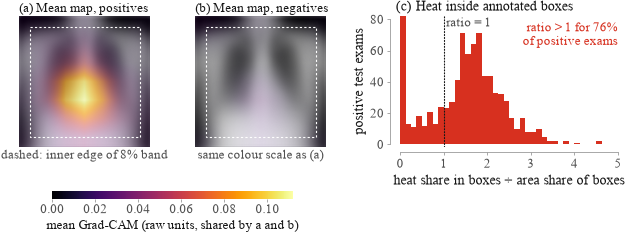

In [52]:
mean_cam = {k: TEST_CAMS_RAW[y_test == k].mean(0) for k in (0, 1)}      # average of the RAW maps
cam_vmax = max(mean_cam[0].max(), mean_cam[1].max())                    # one colour scale for both panels
fig, axes = plt.subplots(1, 3, figsize=figsize("full", aspect=0.38), width_ratios=[1, 1, 1.35])
mean_image = IMAGES[train_rows[:4000]].mean(0) / 255                     # average training radiograph as background
for ax, k, title in [(axes[0], 1, "(a) Mean map, positives"), (axes[1], 0, "(b) Mean map, negatives")]:
    show_xray(ax, mean_image, title=title, note="dashed: inner edge of 8% band" if k == 1 else "same colour scale as (a)")
    overlay_cam(ax, mean_cam[k] / cam_vmax, max_alpha=0.7)
    ax.add_patch(mpatches.Rectangle((bw, bw), IMG_SIZE - 2 * bw, IMG_SIZE - 2 * bw, fill=False,
                                    edgecolor="white", lw=0.8, ls=(0, (2, 2))))
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, cam_vmax)), ax=axes[:2],
                    location="bottom", shrink=0.7, aspect=30, pad=0.02)
cbar.set_label("mean Grad-CAM (raw units, shared by a and b)", fontsize=TICK_PT, color=INK)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=TICK_PT, length=2)
ax = axes[2]
ax.hist(box_ratio, bins=np.linspace(0, 5, 41), color=POS)
ax.axvline(1, color=INK, lw=0.8, ls=":")
ax.set_xlabel("heat share in boxes ÷ area share of boxes")
ax.set_ylabel("positive test exams")
ax.set_title("(c) Heat inside annotated boxes")
finish(ax)
ax.text(0.98, 0.96, f"ratio > 1 for {np.mean(box_ratio > 1):.0%}\nof positive exams", transform=ax.transAxes,
        ha="right", va="top", fontsize=TICK_PT, color=text_color(POS))
ax.text(1.06, ax.get_ylim()[1] * 0.99, "ratio = 1", ha="left", va="top", fontsize=TICK_PT, color=MUTED)
save_and_show(fig, "G4_gradcam_summary")

**Figure G4.** On positive exams the heat concentrates on the annotated opacities (ratio above 1 for 76% of them), while negative exams have much weaker maps. (a, b) Average maps of positives and negatives on one colour scale. (c) Heat share in the boxes divided by their area share; 82 positives (10%) have almost no heat in their boxes.

**Lungs or shortcuts?**

*Signs of lung focus:* on positive exams the boxes cover a median 0.095 of the image but receive 0.171 of the heat (median ratio 1.619, above 1 for 76% of positives), and only 0.185 of their heat falls in the border band, less than its 0.296 share of the image.

*Reasons for caution:*
* Over all exams the border share is 0.442, higher than the band's area. This comes from the negatives (0.517): their maps are about five times weaker, so faint heat at the edges, where text and markers are, takes up a bigger share.
* The average positive map is centred on the heart and the lower middle of the chest rather than on the lungs themselves. The apparent heart size differs between AP and PA images, so a projection cue may play a part.
* Projection (G2) is the strongest shortcut candidate, and it is a property of the whole image, so a heat map cannot isolate it.
* The maps are coarse, with 32 × 32 pixel cells.

Grad-CAM helps us inspect the model but does not prove causation: high heat does not mean a region is needed, and low heat does not mean it is ignored. To test that we have to change the input, which is what X2 does.

---
## X1. Bonus 1: prevalence shift
We build two new test sets from the test split by removing exams of one class only:
* **10% prevalence:** keep all negatives and a random subset of positives;
* **40% prevalence:** keep all positives and a random subset of negatives.

The model and the screening threshold stay exactly the same (no retraining, no re-tuning). We report one seeded draw and repeat the draw 500 times to see how much of the change is sampling noise.

In [53]:
def subsample_to_prevalence(target, rng_s):
    """Indices into the test split with positive prevalence ≈ target, subsampling only one class."""
    pos, neg = np.flatnonzero(y_test == 1), np.flatnonzero(y_test == 0)
    # prevalence = n_pos / (n_pos + n_neg), solved for the class we shrink
    if target < y_test.mean():                                   # too many positives -> drop positives
        n_pos = round(target * len(neg) / (1 - target))
        pos = rng_s.choice(pos, n_pos, replace=False)
    else:                                                        # too many negatives -> drop negatives
        n_neg = round(len(pos) * (1 - target) / target)
        neg = rng_s.choice(neg, n_neg, replace=False)
    return np.sort(np.concatenate([pos, neg]))

def shift_metrics(idx, threshold=rep_thr["screening"]):
    """Metrics of the headline CNN on the test exams `idx`, at the frozen screening threshold."""
    y, p = y_test[idx], rep_test_p[idx]
    m = metrics_at_threshold(y, p, threshold)
    return {"n": len(idx), "positives": int(y.sum()), "prevalence": y.mean(), "sensitivity": m["sensitivity"],
            "specificity": m["specificity"], "precision (PPV)": m["precision"], "F1": m["F1"],
            "AUROC": roc_auc_score(y, p)}

SHIFT_METRICS = ["sensitivity", "specificity", "precision (PPV)", "F1", "AUROC"]
shift_sets = {"10% prevalence": subsample_to_prevalence(0.10, np.random.default_rng(2440)),
              f"original test ({y_test.mean():.1%})": np.arange(len(y_test)),
              "40% prevalence": subsample_to_prevalence(0.40, np.random.default_rng(2440))}
shift_table = pd.DataFrame({k: shift_metrics(v) for k, v in shift_sets.items()}).T
display(style_table(shift_table.astype(float), precision=3,
                    caption=f"Headline CNN, frozen screening threshold t = {rep_thr['screening']:.3f} (one seeded draw)"))

# repeat the random subsampling 500 times to see the sampling spread
rep_draws = {target: pd.DataFrame([shift_metrics(subsample_to_prevalence(target, np.random.default_rng(1000 + r)))
                                   for r in range(500)]) for target in (0.10, 0.40)}
spread = pd.DataFrame({f"{int(t * 100)}%: mean ± SD over 500 draws":
                       rep_draws[t][SHIFT_METRICS].mean().map("{:.3f}".format) + " ± "
                       + rep_draws[t][SHIFT_METRICS].std().map("{:.3f}".format) for t in rep_draws})
display(style_table(spread, caption="Sampling spread of the subsampled test sets"))

,n,positives,prevalence,sensitivity,specificity,precision (PPV),F1,AUROC
10% prevalence,"3,291",329,0.100,0.897,0.642,0.218,0.351,0.859
original test (21.6%),"3,777",815,0.216,0.892,0.642,0.407,0.559,0.862
40% prevalence,"2,037",815,0.400,0.892,0.639,0.622,0.733,0.860


,10%: mean ± SD over 500 draws,40%: mean ± SD over 500 draws
sensitivity,0.892 ± 0.014,0.892 ± 0.000
specificity,0.642 ± 0.000,0.642 ± 0.010
precision (PPV),0.217 ± 0.003,0.624 ± 0.007
F1,0.349 ± 0.005,0.735 ± 0.005
AUROC,0.861 ± 0.008,0.862 ± 0.004


PASS X1_prevalence_shift: 0 errors, 0 warnings, 1 taste notes -> figures/_preview/X1_prevalence_shift.png
  [taste] hierarchy: every series has equal weight; give the claim's series role 'focus' in methods.json


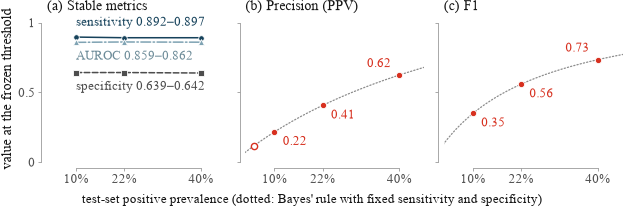

In [54]:
sens_t, spec_t = shift_table.iloc[1][["sensitivity", "specificity"]]
prev_grid = np.linspace(0.01, 0.6, 300)
ppv_curve = sens_t * prev_grid / (sens_t * prev_grid + (1 - spec_t) * (1 - prev_grid))   # Bayes' rule
f1_curve = 2 * ppv_curve * sens_t / (ppv_curve + sens_t)                # F1 = harmonic mean of PPV and sensitivity
ED_PREVALENCE = 0.05                                                  # illustrative low-prevalence setting
ppv_ed = sens_t * ED_PREVALENCE / (sens_t * ED_PREVALENCE + (1 - spec_t) * (1 - ED_PREVALENCE))

fig, axes = plt.subplots(1, 3, figsize=figsize("full", aspect=0.34), sharey=True)
xs = shift_table.prevalence.to_numpy()

def prevalence_axis(ax):
    ax.set_xlim(0.03, 0.46)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0.1, y_test.mean(), 0.4], ["10%", f"{y_test.mean():.0%}", "40%"])
    ax.set_yticks([0, 0.5, 1], ["0", "0.5", "1"])
    for side in ("left", "bottom"):
        ax.spines[side].set_position(("outward", 4))
    ax.spines["bottom"].set_bounds(0.1, 0.4)
    ax.spines["left"].set_bounds(0, 1)

ax = axes[0]                                                   # (a) the metrics that do not move
stable = {"sensitivity": dict(color=PETROL, marker="o", ls="-", dy=6, va="bottom"),
          "AUROC": dict(color=SLATE, marker="^", ls="-.", dy=-6, va="top"),
          "specificity": dict(color=NEUTRALS[0], marker="s", ls="--", dy=-6, va="top")}
for metric, st in stable.items():
    ys = shift_table[metric].to_numpy()
    ax.plot(xs, ys, color=st["color"], ls=st["ls"], lw=1.1, marker=st["marker"], ms=4, mec="white", mew=0.6, label=metric)
    ax.annotate(f"{metric} {ys.min():.3f}–{ys.max():.3f}", (xs[0], ys[0]), xytext=(0, st["dy"]), textcoords="offset points",
                ha="left", va=st["va"], fontsize=TICK_PT, color=text_color(st["color"]))
ax.set_title("(a) Stable metrics")
ax.set_ylabel("value at the frozen threshold")
prevalence_axis(ax)

for ax, metric, curve, title in [(axes[1], "precision (PPV)", ppv_curve, "(b) Precision (PPV)"),
                                 (axes[2], "F1", f1_curve, "(c) F1")]:
    ax.plot(prev_grid, curve, color=NEUTRALS[1], lw=0.9, ls=":", label="_bayes")
    for name in shift_sets:
        r = shift_table.loc[name]
        draws = rep_draws.get(0.10 if name.startswith("10") else 0.40 if name.startswith("40") else None)
        sd = draws[metric].std() if draws is not None else 0
        ax.errorbar(r.prevalence, r[metric], yerr=sd, fmt="o", ms=4.5, color=RED, mec="white", mew=0.6,
                    elinewidth=1.0, zorder=4)
        last = name.startswith("40")
        ax.annotate(f"{r[metric]:.2f}", (r.prevalence, r[metric]), xytext=(-6, 4) if last else (6, -3),
                    textcoords="offset points", ha="right" if last else "left", va="bottom" if last else "top",
                    fontsize=TICK_PT, color=text_color(RED))
    if metric == "precision (PPV)":
        ax.plot(ED_PREVALENCE, ppv_ed, "o", ms=4.5, mfc="white", mec=RED, mew=1.0, label="_ed")
    ax.set_title(title)
    prevalence_axis(ax)
fig.supxlabel("test-set positive prevalence (dotted: Bayes' rule with fixed sensitivity and specificity)", fontsize=TICK_PT, color=INK)
fig.get_layout_engine().set(wspace=0.05)
save_and_show(fig, "X1_prevalence_shift")

**Figure X1.** Going from 40% to 10% prevalence leaves sensitivity, specificity and AUROC unchanged but cuts PPV from 0.62 to 0.22 and F1 from 0.73 to 0.35. The dotted curves are what Bayes' rule predicts from the original sensitivity and specificity; the hollow point is an example at 5% prevalence.

In [55]:
print(f"Bayes' rule at {ED_PREVALENCE:.0%} prevalence with sensitivity {sens_t:.3f} and specificity {spec_t:.3f}: "
      f"PPV = {ppv_ed:.3f} (about {1 / ppv_ed:.0f} flagged exams per true positive)")

Bayes' rule at 5% prevalence with sensitivity 0.892 and specificity 0.642: PPV = 0.116 (about 9 flagged exams per true positive)


**What changed and why.** Prevalence 10% → 21.6% → 40%, same model and threshold:
* **Stayed the same:** sensitivity (0.897 / 0.892 / 0.892), specificity (0.642 / 0.642 / 0.639) and AUROC (0.859 / 0.862 / 0.860). The small differences are within the sampling noise of the 500 draws (± 0.014 for sensitivity at 10%).
* **Changed:** precision/PPV (0.218 / 0.407 / 0.622) and F1 (0.351 / 0.559 / 0.733).

Sensitivity = TP / (TP + FN) only uses positive exams, and specificity = TN / (TN + FP) only uses negative exams. Removing exams of one class at random does not change the scores within each class, so these rates stay the same. AUROC compares pairs of one positive and one negative, so it does not depend on prevalence either. Precision = TP / (TP + FP) mixes the two classes: true positives grow with the share of positives and false positives with the share of negatives. When positives become rare, false positives take over, as Bayes' rule predicts. F1 depends on precision, so it drops too.

The challenge data have 22% positives. In an emergency department with about 5% prevalence, the model would keep its sensitivity and specificity, but its precision would fall to about 0.116, roughly 9 flagged images per real opacity. So precision, F1 and accuracy from a challenge dataset do not carry over: a hospital would need to re-check the model on its own data, recalibrate it and choose its own threshold.

---
## X2. Bonus 2: shortcut stress test with a control
**Border mask:** we replace the outer 8% of the image on each side with the training-mean grey, which is 0 after standardisation. The lungs are left untouched.

**Control mask:** two rectangles with the same total area, placed inside the lungs where training opacities are most common.

If the model mostly uses the lungs, the control should change its predictions much more than the border mask. For every test image we compute Δp = p(masked) − p(original).

In [56]:
# where are the opacities? density of training boxes, at 224-px resolution
box_density = np.zeros((IMG_SIZE, IMG_SIZE))
scale = IMG_SIZE / 1024
for pid in exams.patientId[train_rows]:
    for (x, y, w, h) in BOXES.get(pid, []):
        box_density[int(y * scale):int(np.ceil((y + h) * scale)), int(x * scale):int(np.ceil((x + w) * scale))] += 1
train_boxes = labels_raw[labels_raw.patientId.isin(exams.patientId[train_rows]) & (labels_raw.Target == 1)]
aspect = (train_boxes.height / train_boxes.width).mean()               # average box is taller than wide

control_area = BORDER_MASK.sum() / 2                                   # each of the two rectangles
# width x height = area and height / width = aspect  ->  width = sqrt(area / aspect)
rect_w = int(round(np.sqrt(control_area / aspect)))
rect_h = int(round(control_area / rect_w))
CONTROL_MASK = np.zeros((IMG_SIZE, IMG_SIZE), bool)
control_rects = []
yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]
for half in (xx < IMG_SIZE // 2, xx >= IMG_SIZE // 2):                  # left and right half of the image
    weight = box_density * half
    cy, cx = (weight * yy).sum() / weight.sum(), (weight * xx).sum() / weight.sum()   # centre of the boxes in this half
    top = int(np.clip(round(cy - rect_h / 2), bw, IMG_SIZE - bw - rect_h))     # stay inside the unmasked centre
    left = int(np.clip(round(cx - rect_w / 2), bw, IMG_SIZE - bw - rect_w))
    CONTROL_MASK[top:top + rect_h, left:left + rect_w] = True
    control_rects.append((left, top, rect_w, rect_h))

assert not (CONTROL_MASK & BORDER_MASK).any(), "control must lie inside the unmasked centre"
print(f"border mask : {BORDER_MASK.sum():,} px ({BORDER_MASK.mean():.1%} of the image), band width {bw} px")
print(f"control mask: {CONTROL_MASK.sum():,} px ({CONTROL_MASK.mean():.1%}), two {rect_w} x {rect_h} px rectangles at "
      f"{control_rects}; area ratio control/border = {CONTROL_MASK.sum() / BORDER_MASK.sum():.3f}")

FILL_VALUE = np.uint8(round(PIXEL_MEAN * 255))                         # standardises to ≈ 0

def apply_mask(images_uint8, mask):
    """Deterministic masking: pixels where mask is True get the training-mean grey value."""
    out = images_uint8.copy()
    out[:, mask] = FILL_VALUE                                            # the same pixels in every image
    return out

test_images = IMAGES[test_rows]
p_orig = rep_test_p
p_border = predict(rep_model, CXRDataset(apply_mask(test_images, BORDER_MASK), y_test))
p_control = predict(rep_model, CXRDataset(apply_mask(test_images, CONTROL_MASK), y_test))
dp = {"border": p_border - p_orig, "control": p_control - p_orig}

border mask : 14,832 px (29.6% of the image), band width 18 px
control mask: 14,840 px (29.6%), two 70 x 106 px rectangles at [(34, 60, 70, 106), (121, 63, 70, 106)]; area ratio control/border = 1.001


PASS X2_masks: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/X2_masks.png


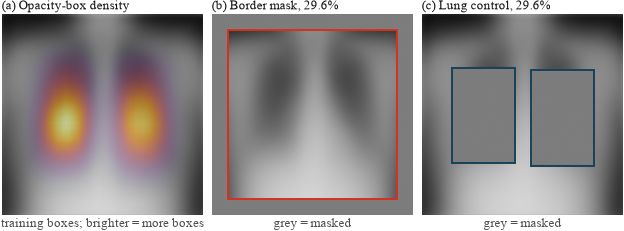

In [57]:
fig, axes = plt.subplots(1, 3, figsize=figsize("full", aspect=0.38))
panels = [(None, "(a) Opacity-box density"), (BORDER_MASK, f"(b) Border mask, {BORDER_MASK.mean():.1%}"),
          (CONTROL_MASK, f"(c) Lung control, {CONTROL_MASK.mean():.1%}")]
for ax, (mask, title) in zip(axes, panels):
    shown = mean_image.copy()
    if mask is not None:
        shown[mask] = PIXEL_MEAN                                      # what the model sees: training-mean grey
    show_xray(ax, shown, title=title, note="training boxes; brighter = more boxes" if mask is None else "grey = masked")
    ax.images[0].set_clim(0, 1)
    if mask is None:
        overlay_cam(ax, box_density / box_density.max(), max_alpha=0.65)
    elif mask is BORDER_MASK:
        ax.add_patch(mpatches.Rectangle((bw - 0.5, bw - 0.5), IMG_SIZE - 2 * bw, IMG_SIZE - 2 * bw, fill=False,
                                        edgecolor=RED, lw=1.4))
    else:
        for (left, top, w, h) in control_rects:
            ax.add_patch(mpatches.Rectangle((left - 0.5, top - 0.5), w, h, fill=False, edgecolor=PETROL, lw=1.4))
save_and_show(fig, "X2_masks")

**Figure X2a.** The border mask and the lung control hide the same share of the image (29.6%). (a) Where the training opacities are, which positions the control. (b) Border mask. (c) Lung control.

,AUROC unmasked,mean Δp,median Δp,median |Δp|,95th pct |Δp|,share |Δp| > 0.10,AUROC after masking,sensitivity after masking,specificity after masking
border mask,0.862,0.012,0.011,0.045,0.214,0.246,0.858,0.871,0.635
lung-field control,0.862,-0.032,0.021,0.237,0.501,0.828,0.711,0.683,0.641


paired Wilcoxon signed-rank test, |Δp| border vs control: statistic 554702, p < 1e-300 (below floating-point range); |Δp| border > control in 16.6% of images
  negatives: mean Δp border +0.017, control +0.042
  positives: mean Δp border -0.007, control -0.300


PASS X2_delta_p: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/X2_delta_p.png


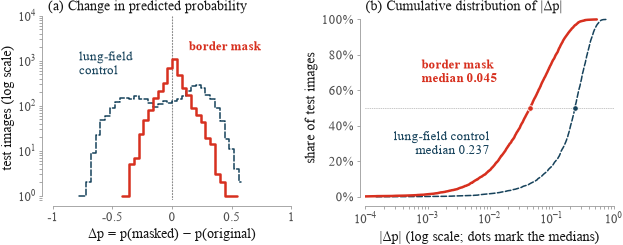

In [58]:
def dp_summary(d, p_masked):
    return {"mean Δp": d.mean(), "median Δp": np.median(d), "median |Δp|": np.median(np.abs(d)),
            "95th pct |Δp|": np.percentile(np.abs(d), 95), "share |Δp| > 0.10": (np.abs(d) > 0.10).mean(),
            "AUROC after masking": roc_auc_score(y_test, p_masked),
            "sensitivity after masking": metrics_at_threshold(y_test, p_masked, rep_thr["screening"])["sensitivity"],
            "specificity after masking": metrics_at_threshold(y_test, p_masked, rep_thr["screening"])["specificity"]}

from scipy.stats import wilcoxon
dp_table = pd.DataFrame({"border mask": dp_summary(dp["border"], p_border),
                         "lung-field control": dp_summary(dp["control"], p_control)}).T
dp_table.insert(0, "AUROC unmasked", roc_auc_score(y_test, p_orig))
display(style_table(dp_table, precision=3, caption=f"Change in predicted probability, Δp = p(masked) − p(original); n = {len(y_test):,}"))
# paired test on the same images: is |Δp| systematically different between the two masks?
stat = wilcoxon(np.abs(dp["border"]), np.abs(dp["control"]))
p_text = f"p = {stat.pvalue:.1e}" if stat.pvalue > 0 else "p < 1e-300 (below floating-point range)"
print(f"paired Wilcoxon signed-rank test, |Δp| border vs control: statistic {stat.statistic:.0f}, {p_text}; "
      f"|Δp| border > control in {(np.abs(dp['border']) > np.abs(dp['control'])).mean():.1%} of images")
for k in (0, 1):
    sel = y_test == k
    print(f"  {'positives' if k else 'negatives'}: mean Δp border {dp['border'][sel].mean():+.3f}, control {dp['control'][sel].mean():+.3f}")

fig, axes = plt.subplots(1, 2, figsize=figsize("full", aspect=0.40))
mask_style = {"border": dict(color=RED, lw=1.8, ls="-", zorder=4),
              "control": dict(color=PETROL, lw=1.1, ls="--", zorder=3)}
mask_name = {"border": "border mask", "control": "lung-field control"}

ax = axes[0]                                                   # (a) distribution of Δp
lim = np.ceil(max(np.abs(dp["border"]).max(), np.abs(dp["control"]).max()) * 10) / 10
bins = np.linspace(-lim, lim, 41)
for key in ("control", "border"):
    counts_, edges = np.histogram(dp[key], bins=bins)
    nz = np.flatnonzero(counts_)
    keep = slice(nz[0], nz[-1] + 1)                            # stop at the first/last non-empty bin
    ax.plot(((edges[:-1] + edges[1:]) / 2)[keep], np.maximum(counts_, 0.8)[keep], drawstyle="steps-mid",
            label=mask_name[key], **mask_style[key])
ax.axvline(0, color=NEUTRALS[1], lw=0.8, ls=":")
ax.set_yscale("log")
ax.set_ylim(0.8, 1e4)
ax.set_xlabel("Δp = p(masked) − p(original)")
ax.set_ylabel("test images (log scale)")
ax.set_title("(a) Change in predicted probability")
finish(ax)
ax.text(0.14, 1500, "border mask", ha="left", va="bottom", fontsize=TICK_PT, fontweight="bold", color=text_color(RED))
ax.text(-0.78, 420, "lung-field\ncontrol", ha="left", va="bottom", fontsize=TICK_PT, color=text_color(PETROL))

ax = axes[1]                                                   # (b) ECDF of |Δp|
med = {}
for key in ("control", "border"):
    v = np.sort(np.abs(dp[key]))
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), label=mask_name[key], **mask_style[key])
    med[key] = np.median(np.abs(dp[key]))
    ax.plot(med[key], 0.5, "o", ms=4, color=mask_style[key]["color"], mec="white", mew=0.6, zorder=5, label="_median")
ax.axhline(0.5, color=NEUTRALS[2], lw=0.6, ls=":", zorder=1)
ax.set_xscale("log")
ax.set_xlim(1e-4, 1)
ax.set_xlabel("|Δp| (log scale; dots mark the medians)")
ax.set_ylabel("share of test images")
ax.set_title("(b) Cumulative distribution of |Δp|")
finish(ax, y="pct1")
place_text(ax, f"border mask\nmedian {med['border']:.3f}", prefer=(0.25, 0.75), fontweight="bold", color=text_color(RED))
place_text(ax, f"lung-field control\nmedian {med['control']:.3f}", prefer=(0.98, 0.03), color=text_color(PETROL))
save_and_show(fig, "X2_delta_p")

**Figure X2b.** Hiding the lungs changes the predictions about five times more than hiding the border (median |Δp| 0.237 vs 0.045).

,label,view,p before,p after,Δp
exam,,,,,
1,negative,PA,0.178,0.713,0.535
2,negative,PA,0.311,0.818,0.507
3,positive,PA,0.172,0.648,0.476


PASS X2_gradcam_top3: 0 errors, 0 warnings, 0 taste notes -> figures/_preview/X2_gradcam_top3.png


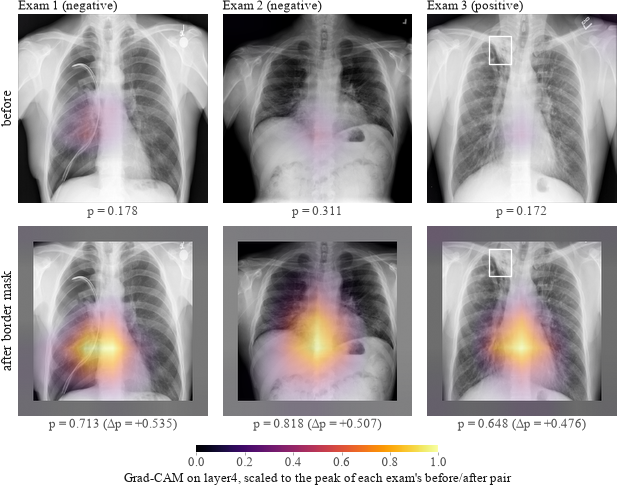

In [59]:
top3 = np.argsort(-np.abs(dp["border"]))[:3]                           # positions of the 3 largest |Δp|
masked_border_ds = CXRDataset(apply_mask(test_images[top3], BORDER_MASK), y_test[top3])
cams_before = grad_cam(rep_model, torch.stack([test_ds[i][0] for i in top3]), rep_model.layer4)[0]
cams_after = grad_cam(rep_model, torch.stack([masked_border_ds[j][0] for j in range(3)]), rep_model.layer4)[0]
row_max = np.maximum(cams_before.max(axis=(1, 2)), cams_after.max(axis=(1, 2)))[:, None, None]   # per exam
cams_before, cams_after = cams_before / row_max, cams_after / row_max       # same colour scale before and after

fig, axes = plt.subplots(2, 3, figsize=figsize("full", aspect=0.78))
top3_rows = []
for c, i in enumerate(top3):
    row = test_exams.loc[i]
    for r, (img, cam, p, label) in enumerate([(test_images[i], cams_before[c], p_orig[i], "before"),
                                               (apply_mask(test_images[i:i + 1], BORDER_MASK)[0], cams_after[c],
                                                p_border[i], "after border mask")]):
        show_xray(axes[r, c], img, title=f"Exam {c + 1} ({'positive' if row.y else 'negative'})" if r == 0 else None,
                  note=f"p = {p:.3f}" + (f" (Δp = {dp['border'][i]:+.3f})" if r else ""),
                  boxes=BOXES.get(row.patientId), box_scale=IMG_SIZE / 1024, box_color="white")
        overlay_cam(axes[r, c], cam)
    top3_rows.append({"exam": c + 1, "label": "positive" if row.y else "negative", "view": row.view,
                      "p before": p_orig[i], "p after": p_border[i], "Δp": dp["border"][i]})
axes[0, 0].set_ylabel("before", fontsize=LABEL_PT, color=INK)
axes[1, 0].set_ylabel("after border mask", fontsize=LABEL_PT, color=INK)
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1)), ax=axes, location="bottom",
                    shrink=0.4, aspect=35, pad=0.03)
cbar.set_label("Grad-CAM on layer4, scaled to the peak of each exam's before/after pair", fontsize=TICK_PT, color=INK)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=TICK_PT, length=2)
display(style_table(pd.DataFrame(top3_rows).set_index("exam"), precision=3, caption="The three largest border-mask changes"))
save_and_show(fig, "X2_gradcam_top3")

**Figure X2c.** The three largest border changes are all increases of about 0.5 (+0.476 to +0.535), two of them on negative exams. After masking, the heat moves to the centre of the chest rather than onto the grey frame, so the unnatural frame seems to change how the model reads the whole image.

**What the control is for and what we can conclude.** Masking the border barely changes the model: median |Δp| 0.045 and AUROC 0.862 → 0.858. Masking the same area inside the lungs changes it a lot: median |Δp| 0.237, AUROC 0.711, and positive exams lose 0.300 of probability on average. The border change is smaller than the control change for 83% of images (paired Wilcoxon test, P < 0.001), although 0.246 of images still move by more than 0.10 under the border mask.

We need the control because covering 30% of an image is itself an unusual change, and the model might react to the grey block rather than to what it hides. Using the same fill on an equal area of the lungs lets us compare where the information was removed.

We can conclude that the lungs carry much more of the model's signal than the border. We cannot conclude that the model uses no shortcuts: the projection cue is spread over the whole image and survives border masking, the control also hides the disease itself, and we only tried one mask size, fill value and model.

Even if the border effect had been larger than the control effect, it would be evidence, not proof, of shortcut use. Masking shows that the output depends on a region, but not which content in it matters: masked images look unlike the training data, and the border also contains anatomy such as the shoulders and lung tops.